# Network signs of emergence in new medical terms: RQ1 replication on held-out MeSH concepts

This notebook is a runnable demo of **`method.py`**. That script asks whether network *precursors* of scientific emergence, first found in a main OpenAlex concept pool, also show up in an independent biomedical population: **191 held-out MeSH concepts** (population `mesh_heldout`). It uses only the co-occurrence network, costs nothing to run and needs only a CPU.

`method.py` has three stages:

| stage | what it does | in this notebook |
|---|---|---|
| `snapshots` (STEP 0-2) | 25 yearly 3-year co-occurrence snapshots built from a post-stratified sample of 259,716 works; best-of-5 Leiden communities; attaches each MeSH concept to its snapshot | **not re-run.** It needs the multi-GB background sample and about 3 CPU-hours. Its output is the frozen feature table in `mini_demo_data.json` |
| `features` (STEP 3) | indicators for each concept-year (degree/strength, new relations, Baselga turnover, accretion share, closure vs. a Chung-Lu null, participation P, within-module z, betweenness, ...). The table is frozen and sha256-hashed **before** any outcome is looked at | loaded from `mini_demo_data.json`; the T6 sanity check is re-run |
| `outcomes` (STEP 4-9) | emergence labels → 1:3 matched controls → event study (concept-bootstrap CIs, Holm correction, permutation MDE) → main-pool-aligned block → rolling-origin and grouped-CV prediction → 3 pattern rules → verdict | **run in full, code unchanged**, on a 100-concept subset with fewer bootstrap draws |

**Precursors tested** (all fixed in advance): `accretion_share` (share of strength growth that comes from brand-new neighbours), `closure_lr` (log ratio of observed to expected closure among the top-20 neighbours under a Chung-Lu null) and `dP` (change in the participation coefficient across communities).

**Results of the full run** (191 concepts, BOOT=2000): with the plan-native PRIMARY definition (18 emerging concepts, n_eff 15), none of the three precursors was detected (all Holm p > 0.48, MDE 0.43-0.56 SD). In SENS1 (n=29), closure was *lower* before emergence (closure_lr -0.42 [-0.74, -0.11], Holm p=0.039), the same direction as in the main pool. The precursors add nothing to prediction beyond frequency/burst and degree/centrality (grouped-CV ΔAUC(B-A) = +0.002). Pattern rules: early bridging 59%, incubation followed by expansion 17%, gradual centralisation 1.6%.

> The demo subset is **not** a random sample. It keeps the 35 concepts that emerged under PRIMARY, SENS1 or SENS2 in the full run and adds 65 others at random, so labels still occur. Effect sizes and CIs will therefore differ from the full run. Because the control pool is smaller, only 14 of the 18 PRIMARY-emerging concepts find matched controls here (15 in the full run), so the PRIMARY verdict comes out as *UNDERPOWERED (F5)* rather than *NOT DETECTED*. With the demo config, the whole notebook runs in about 4-5 minutes on a CPU.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru: NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib, pyarrow: pre-installed on Colab, install locally only (Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0', 'pyarrow==18.1.0')

## Imports
These are the original import blocks of `method.py` and `analysis.py`. In the original, `rq1_spec`, `analysis`, `features` and `load` are local modules. Here their code (or the one function needed from each) is defined in later cells, and the result is exposed under the same names `S`, `A`, `FT` and `load`. That way the body of `method.py` runs unchanged.

In [2]:
# --- method.py imports
from __future__ import annotations

import argparse
import glob
import os
import json
import resource
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

# --- analysis.py imports
import hashlib
from scipy.stats import kendalltau
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# --- notebook-only
import types
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)  # nanmean of all-NaN event-time slices (expected)
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
from IPython.display import Image, display

## Load the demo data (GitHub URL, with a local fallback)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-2/experiment-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(len(data["examples"]), "concepts;", len(data["examples"][0]["features"]["year"]), "yearly feature rows per concept")

Held-out MeSH RQ1 demo subset: 100 concepts (concept table row + frozen yearly network features 2000-2024 from features.parquet). Selection: all 35 concepts that emerged under PRIMARY/SENS1/SENS2 in the full 191-concept run + 65 random others (seed 42).
100 concepts; 25 yearly feature rows per concept


## Config
These are all the tunable parameters. The demo values are small so that the whole notebook finishes in a few minutes. The original values (from `rq1_spec.py`) are in the comments; the full run took about 480 s for the outcomes stage on 191 concepts. The cell after the spec cell writes these values into the spec namespace `S`.

In [5]:
N_CONCEPTS = 100        # concepts used from mini_demo_data.json (max 100 in the file; the full run used 191)
BOOT = 1000             # concept-bootstrap draws for CIs            (original: 2000)
PERM_MDE = 300          # permutations for the minimum detectable effect (original: 500)
NULL_PERMS = 100        # T5 onset-permutation null replications     (original: 200)
LABEL_PERM_REPS = 5     # label-permutation delta-AUC null reps      (original: 5, hard-coded in method.py)
GROUPED_CV_FOLDS = 5    # grouped (by concept) CV folds             (original: 5)
_CONFIG = dict(BOOT=BOOT, PERM_MDE=PERM_MDE, NULL_PERMS=NULL_PERMS, GROUPED_CV_FOLDS=GROUPED_CV_FOLDS)

## Frozen specification (`rq1_spec.py`, verbatim)
Every constant used by the pipeline is defined here. In the original run, the sha256 of this file is written to `results/prereg_spec.json` before any outcome is computed. A key declared choice is `E_CENT_REFERENCE = "focal"`: focal MeSH nodes sit around the 2nd percentile of strength among *all* nodes, so the plan-literal 20-point all-node percentile gain is almost unreachable. PRIMARY `E_cent` therefore uses the percentile within the focal population.

In [6]:
POPULATION = "mesh_heldout"
SEED = 42

# ---- snapshots
YEARS = list(range(2000, 2025))
WINDOW = 3  # trailing window y-2..y, for background AND focal attachment (declared)
TAG_MIN_SCORE = 0.3
EXCLUDE_LEVEL0 = True
EDGE_MIN_WCOUNT = 2.0  # on weighted co-occurrence W_ij (population-count units)
LEIDEN = {
    "partition": "RBConfigurationVertexPartition",
    "resolution": 1.0,
    "seeds": [42, 43, 44, 45, 46],  # n_starts = 5, keep max quality
    "n_iterations": 2,  # DEVIATION from plan (-1): measured 95 s/seed/snapshot at -1 (3.3 CPU-h total);
    # n_iterations=2 reaches 99.6% of the -1 quality on the 2014 snapshot (see results/prereg_spec.json)
    "weight": "association_strength",
}
COMMUNITY_MATCH_JACCARD = 0.3
LEIDEN_TIMEOUT_S = 600  # F2: fall back to ModularityVertexPartition if slower
TOPK_CLOSURE = 20
REWIRE_FRAC = 0.10
REWIRE_REPS = 20
REWIRE_SWAPS_PER_EDGE = 10
BETWEENNESS_SAMPLES = 500

# ---- emergence labels
AGE_RANGE = (3, 8)
T_MAX = 2019
E_MIN_MEAN = 20.0
E_MAX_FALL = 0.30  # V[t+5] >= (1 - 0.30) * V[t+1]
E_PCTL_GAIN = 20.0
# Percentile reference for E_cent (declared BEFORE outcomes, from the mini feature distribution only):
# 'focal' = percentile of weighted degree among the non-isolated MeSH focal nodes of snapshot y;
# 'all_nodes' = plan-literal reference (bg + focal nodes). In the mini run every focal concept-year sat at the
# 0.04-1.5th percentile of all nodes (sampled legacy tags each stand for hundreds of population works), so a
# 20-point gain is structurally infeasible there; 'all_nodes' is still labelled and reported (E_cent_allnodes).
E_CENT_REFERENCE = "focal"
HORIZON = 5
VOLUME_DEFS = ["PRIMARY_tm", "SENS1_tm_plus_np", "SENS2_mesh_indexed"]

# ---- matching
MATCH_VOL_TOL = 0.20
MATCH_VOL_TOL_WIDE = 0.30
MATCH_RATIO = 3
F_BANDS = {"2005-07": (2005, 2007), "2008-11": (2008, 2011), "2012-16": (2012, 2016)}  # dataset_1 metadata_F_band

# ---- event study
EVENT_REL = [-5, -4, -3, -2, -1]
PRIMARY_EVENT_WINDOW = [-3, -2, -1]
PRECURSORS = ["accretion_share", "closure_lr", "dP"]
BOOT = 2000
PERM_MDE = 500
NULL_PERMS = 200

# ---- rolling-origin prediction
ORIGINS = list(range(2012, 2020))
TRAIN_LAG = 5  # train units have t <= T - 5
MIN_TRAIN_UNITS = 30
MIN_TRAIN_POS = 5
LOGREG = {"penalty": "l2", "C": 1.0, "class_weight": None, "max_iter": 5000}
GROUPED_CV_FOLDS = 5
KLEINBERG = {"s": 2.0, "gamma": 1.0}

# ---- patterns
PATTERN_QUIET_YEARS = 2
PATTERN_GROWTH_PCTL = 90
PATTERN_TAU = 0.5
PATTERN_CENTRAL_YEARS = 3
PATTERN_P_LOW = 0.3
PATTERN_P_HIGH = 0.6
PATTERN_BETW_DECILE = 0.9
PATTERN_EARLY_YEARS = 2

# ---- main-pool alignment (sibling iteration-2 main-pool RQ1 run found at run time: gen_art_experiment_3,
# spec.json sha256 d61374e1..., lib_metrics.py sha256 ecc07a08... vendored read-only as vendor/mainpool_lib_metrics.py).
# Added BEFORE any outcome of this population was computed; the plan-native block above is unchanged.
MAINPOOL = {
    "source": "iter_2/gen_art/gen_art_experiment_3 (spec.json, lib_metrics.py, stage_snapshots.py, stage_indicators.py, analysis_event.py)",
    "precursors": ["accretion_shift_rar", "closure", "P_rar"],
    "families": {"accretion": ["accretion_shift_rar", "accretion_shift_raw", "accretion_shift_rar_res"],
                 "closure": ["closure", "closure_raw", "closure_res"],
                 "participation": ["P_rar", "P_raw", "P_rar_res"]},
    "exploratory": ["new_rel_rate", "nbr_novelty", "beta_sim_rar", "beta_sne_rar", "sne_share_rar", "z_within", "betw",
                    "comm_change", "n_modules_touched", "subfield_entropy", "burst_active_tm", "accretion_shift_rar5",
                    "P_rar_m5", "wdeg_pctl_focal", "log_vol3", "wdeg_pctl", "growth"],
    "labels": {"E": "uptake AND all-node percentile gain >= 20 (main-pool primary)",
               "E_alt": "uptake AND focal-population percentile gain >= 20 (main-pool E_alt)",
               "E_up": "uptake only (mean >= 20 over t+1..t+5, no fall > 30%)"},
    "es_rel_years": [-5, -4, -3, -2, -1, 0],  # calendar year = t0 + k, t0 = onset label year
    "es_summary_window": [-3, 0],
    "controls": "never-emerging concepts (no onset in the eligible window), same F-band and origin group, "
                "nearest on log vol3 within +-20% (else +-30%), 1:3 with replacement",
    "origin_group": "OpenAlex origin field (the main pool's origin group is its stratum prefix, an OpenAlex field or "
                    "domain id such as F31 / D3)",
    "mde": "2.8 x bootstrap SE / pooled SD",
}

In [7]:
# expose the spec as the module-like namespace `S` that method.py / analysis.py use (import rq1_spec as S)
S = types.SimpleNamespace(**{k: v for k, v in dict(globals()).items() if k.isupper() and not k.startswith("_")})
# demo overrides from the Config cell (the original values are the ones printed in the spec cell above)
for _k, _v in _CONFIG.items():
    setattr(S, _k, _v)
print({"BOOT": S.BOOT, "PERM_MDE": S.PERM_MDE, "NULL_PERMS": S.NULL_PERMS, "GROUPED_CV_FOLDS": S.GROUPED_CV_FOLDS})

{'BOOT': 1000, 'PERM_MDE': 300, 'NULL_PERMS': 100, 'GROUPED_CV_FOLDS': 5}


## Rebuild the input tables from the demo data
This cell replaces the original `pd.read_parquet(...)` calls: `results/features.parquet` (the frozen concept-year features), `results/intermediate/concepts.parquet` (the concept table with yearly volume series `tm_*` / `s1_*` / `mi_*`) and dataset_2's `taxonomy_fields.parquet` (the field → domain map). `load.f_band` and `features.indicator_columns` are the only other helpers `method.py` needs, and they are defined here too.

In [8]:
ROOT = Path(".").resolve()
RES = ROOT / "results"
FIG = ROOT / "figures"
RES.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(str(ROOT / "logs" / "run.log"), rotation="30 MB", level="DEBUG")


# ---- load.py: f_band (verbatim)
def f_band(F: int) -> str:
    for name, (a, b) in S.F_BANDS.items():
        if a <= F <= b:
            return name
    return "other"


load = types.SimpleNamespace(f_band=f_band)
# ---- features.py: indicator_columns() (its output, results/indicator_columns.json, ships with the demo data)
FT = types.SimpleNamespace(indicator_columns=lambda: data["indicator_columns"])

# ---- tables that the original reads from parquet
_ex = data["examples"][:N_CONCEPTS]
DEMO_CONCEPTS = pd.DataFrame([{k: v for k, v in e.items() if k != "features"} for e in _ex])
_rows = []
for e in _ex:
    fe = e["features"]
    for i in range(len(fe["year"])):
        _rows.append({"concept_id": e["concept_id"], **{c: fe[c][i] for c in fe}})
DEMO_FEAT = pd.DataFrame(_rows)
for c, dt in data["feature_dtypes"].items():
    if dt in ("float64", "int64"):
        DEMO_FEAT[c] = DEMO_FEAT[c].astype(dt)
DEMO_TAX = pd.DataFrame({"field_id": [int(k) for k in data["field_to_domain"]],
                         "domain_id": list(data["field_to_domain"].values())})
print("features:", DEMO_FEAT.shape, " concepts:", DEMO_CONCEPTS.shape)

features: (2500, 112)  concepts: (100, 90)


### STEP 3 sanity check (from `stage_features`)
The only part of the `features` stage re-run here is **T6**: the all-node weighted-degree percentile should follow log volume, and so should the focal-population percentile. The same cell also shows how low the focal concepts sit in the all-node strength distribution. That is the design fact that motivates `E_CENT_REFERENCE = "focal"`.

In [9]:
feat = DEMO_FEAT
# T6 sanity: centrality percentile tracks volume
net = feat[feat.k > 0]
r = float(np.corrcoef(net.wdeg_pctl, np.log1p(net.W_c))[0, 1]) if len(net) > 2 else np.nan
r_f = float(np.corrcoef(net.wdeg_pctl_focal, np.log1p(net.W_c))[0, 1]) if len(net) > 2 else np.nan
print(f"T6 corr(wdeg_pctl, log W_c) = {r:.3f};  corr(wdeg_pctl_focal, log W_c) = {r_f:.3f}")
print("all-node strength percentile of focal concept-years:",
      {q: round(float(net.wdeg_pctl.quantile(q)), 2) for q in (0.5, 0.9, 0.99, 1.0)})

T6 corr(wdeg_pctl, log W_c) = 0.793;  corr(wdeg_pctl_focal, log W_c) = 0.732
all-node strength percentile of focal concept-years: {0.5: 1.5, 0.9: 11.6, 0.99: 29.86, 1.0: 69.95}


## `analysis.py`: emergence labels and matching (STEPs 4-5), verbatim
* **Labels.** For each concept and year t in 2005-2019: `E_vol` means uptake, i.e. mean yearly volume over t+1..t+5 is at least 20 and the last year has fallen by no more than 30%. `E_cent` means the centrality percentile rises by at least 20 points between t and t+5. `E = E_vol AND E_cent`. The three volume definitions are PRIMARY = verified text match, SENS1 = PRIMARY plus non-PubMed works, and SENS2 = MeSH-indexed works.
* **Onset.** The first t with E=1, searched at concept ages 3-8 and t ≤ 2019.
* **Matching.** Each emerging concept gets 3 controls with the nearest volume, drawn from the same F-band and origin field. The volume tolerance is ±20%, widened to ±30% if needed. Controls are drawn with replacement and must not be emerging at t*.

In [10]:
VOL_KEY = {"PRIMARY": "tm", "SENS1": "s1", "SENS2": "mi"}


# =================================================================== STEP 4 labels
def label_table(feat: pd.DataFrame, concepts: pd.DataFrame) -> pd.DataFrame:
    """E_vol / E_cent / E for every concept and t in 2005..2019 under the three volume definitions."""
    pcol = "wdeg_pctl_focal" if S.E_CENT_REFERENCE == "focal" else "wdeg_pctl"
    pct_lut = {(c, y): v for c, y, v in zip(feat.concept_id, feat.year, feat[pcol])}
    pct_all_lut = {(c, y): v for c, y, v in zip(feat.concept_id, feat.year, feat.wdeg_pctl)}
    rows = []
    cmeta = concepts.set_index("concept_id")
    for cid in concepts.concept_id:
        F = int(cmeta.at[cid, "F"])
        de = int(cmeta.at[cid, "de_year"])
        pct = {y: pct_lut.get((cid, y), np.nan) for y in S.YEARS}
        pct = {y: (0.0 if pd.isna(v) else float(v)) for y, v in pct.items()}  # isolated focal node = bottom
        pall = {y: pct_all_lut.get((cid, y), np.nan) for y in S.YEARS}
        pall = {y: (0.0 if pd.isna(v) else float(v)) for y, v in pall.items()}
        for t in range(2005, S.T_MAX + 1):
            r = {"concept_id": cid, "t": t, "age": t - F, "F": F}
            r["in_age_range"] = S.AGE_RANGE[0] <= t - F <= S.AGE_RANGE[1]
            r["E_cent"] = int(pct[t + S.HORIZON] - pct[t] >= S.E_PCTL_GAIN)
            r["pctl_gain"] = pct[t + S.HORIZON] - pct[t]
            r["E_cent_allnodes"] = int(pall[t + S.HORIZON] - pall[t] >= S.E_PCTL_GAIN)
            r["pctl_gain_allnodes"] = pall[t + S.HORIZON] - pall[t]
            r["E_allnode_PRIMARY"] = 0  # filled below once E_vol_PRIMARY is known
            for vd, k in VOL_KEY.items():
                V = np.array([float(cmeta.at[cid, f"{k}_{y}"]) for y in range(t + 1, t + S.HORIZON + 1)])
                ev = int(V.mean() >= S.E_MIN_MEAN and V[-1] >= (1 - S.E_MAX_FALL) * V[0])
                r[f"E_vol_{vd}"] = ev
                r[f"E_{vd}"] = int(ev and r["E_cent"])
                r[f"V_t_{vd}"] = float(cmeta.at[cid, f"{k}_{t}"])
            r["E_allnode_PRIMARY"] = int(r["E_vol_PRIMARY"] and r["E_cent_allnodes"])
            # SENS2: MeSH-indexed series is structurally zero before DateEstablished
            r["sens2_valid"] = t >= de
            rows.append(r)
    return pd.DataFrame(rows)


def onsets(lab: pd.DataFrame, vd: str, outcome: str | None = None, t_max: int = S.T_MAX) -> dict[str, int]:
    col = outcome or f"E_{vd}"
    u = lab[lab.in_age_range & (lab.t <= t_max)]
    if vd == "SENS2":
        u = u[u.sens2_valid]
    u = u[u[col] == 1]
    return u.groupby("concept_id").t.min().to_dict()


# =================================================================== STEP 5 matching
def match_controls(lab: pd.DataFrame, concepts: pd.DataFrame, onset: dict[str, int], vd: str,
                   outcome_col: str, group_col: str = "origin_field", eligible: set | None = None,
                   check_label: bool = True) -> tuple[list[dict], dict]:
    """1:3 nearest-volume matching within F-band x group, +-20% (widen to +-30%), with replacement."""
    cm = concepts.set_index("concept_id")
    L = lab.set_index(["concept_id", "t"])
    sets = []
    n20 = n30 = n_any = 0
    pool = [c for c in concepts.concept_id if eligible is None or c in eligible]
    for c, ts in sorted(onset.items()):
        if eligible is not None and c not in eligible:
            continue
        Vc = float(L.at[(c, ts), f"V_t_{vd}"])
        cands = []
        for c2 in pool:
            if c2 == c or cm.at[c2, "F_band"] != cm.at[c, "F_band"] or cm.at[c2, group_col] != cm.at[c, group_col]:
                continue
            o2 = onset.get(c2)
            if o2 is not None and o2 <= ts:
                continue
            if check_label and L.at[(c2, ts), outcome_col] == 1:
                continue
            V2 = float(L.at[(c2, ts), f"V_t_{vd}"])
            rel = abs(V2 / Vc - 1) if Vc > 0 else (0.0 if V2 == 0 else np.inf)
            cands.append((abs(np.log1p(V2) - np.log1p(Vc)), rel, c2))
        cands.sort()
        tol = S.MATCH_VOL_TOL
        ctrl = [x for x in cands if x[1] <= tol][: S.MATCH_RATIO]
        if len(ctrl) < S.MATCH_RATIO:
            tol = S.MATCH_VOL_TOL_WIDE
            ctrl = [x for x in cands if x[1] <= tol][: S.MATCH_RATIO]
        full = len(ctrl) == S.MATCH_RATIO
        n20 += int(full and tol == S.MATCH_VOL_TOL)
        n30 += int(full)
        n_any += int(len(ctrl) > 0)
        sets.append({"concept_id": c, "t_star": ts, "controls": [x[2] for x in ctrl], "tol": tol,
                     "k": len(ctrl), "V": Vc})
    n = len(sets)
    info = {"n_emerging": n, "match_rate_3_at_20pct": n20 / n if n else np.nan,
            "match_rate_3_at_30pct": n30 / n if n else np.nan, "match_rate_any": n_any / n if n else np.nan,
            "F7_all_available_controls": bool(n and n30 / n < 0.5),
            "n_controls_total": int(sum(s["k"] for s in sets)),
            "n_unique_controls": len({c for s in sets for c in s["controls"]})}
    return sets, info

## `analysis.py`: event study and multiple-testing helpers (STEP 6), verbatim
For each matched set, the per-year difference is the emerging concept's value minus the mean of its controls. It is computed at event years rel = -5..-1, where rel k is calendar year t*+1+k. The summary statistic **D** is the mean difference over rel -3..-1. CIs come from a concept bootstrap over matched sets (`BOOT` draws). The **MDE** is 2.8 × the SD of a within-set permutation null (`PERM_MDE` draws), where any member of a set may be relabelled as the emerging one. The three pre-named precursors are Holm-corrected together, and all other indicators are BH-corrected.

In [11]:
def set_matrices(sets: list[dict], feat_idx: pd.DataFrame, col: str) -> list[np.ndarray]:
    """For each matched set: array (1 + k) x len(EVENT_REL); row 0 = emerging. rel k <-> year t*+1+k."""
    out = []
    for s in sets:
        if s["k"] == 0:
            continue
        yrs = [s["t_star"] + 1 + k for k in S.EVENT_REL]
        mem = [s["concept_id"]] + s["controls"]
        M = np.full((len(mem), len(yrs)), np.nan)
        for i, c in enumerate(mem):
            for j, y in enumerate(yrs):
                if (c, y) in feat_idx.index:
                    M[i, j] = feat_idx.at[(c, y), col]
        out.append(M)
    return out


def _diffs(mats: list[np.ndarray], pick: np.ndarray | None = None) -> np.ndarray:
    """diff_{i,k} = emerging - mean(controls); pick[i] = which row plays 'emerging' (permutation null)."""
    D = np.full((len(mats), len(S.EVENT_REL)), np.nan)
    for i, M in enumerate(mats):
        e = 0 if pick is None else pick[i]
        rest = np.delete(M, e, axis=0)
        with np.errstate(all="ignore"):
            cmean = np.nanmean(rest, axis=0) if rest.shape[0] else np.full(M.shape[1], np.nan)
        D[i] = M[e] - cmean
    return D


def _summ(D: np.ndarray, w_idx: list[int]) -> tuple[np.ndarray, float]:
    with np.errstate(all="ignore"):
        dk = np.nanmean(D, axis=0)
        return dk, float(np.nanmean(dk[w_idx]))


def event_study(mats: list[np.ndarray], rng: np.random.Generator, sd_ref: float, do_mde: bool = True) -> dict:
    w_idx = [S.EVENT_REL.index(k) for k in S.PRIMARY_EVENT_WINDOW]
    D = _diffs(mats)
    n = len(mats)
    res = {"n_sets": n, "n_controls": int(sum(M.shape[0] - 1 for M in mats)),
           "n_eff": int((~np.isnan(D[:, w_idx])).any(axis=1).sum()) if n else 0,
           "n_at_rel": (~np.isnan(D)).sum(axis=0).tolist() if n else [0] * len(S.EVENT_REL)}
    if n == 0 or np.all(np.isnan(D)):
        res.update({"d_k": [np.nan] * len(S.EVENT_REL), "D": np.nan, "ci_k": [(np.nan, np.nan)] * len(S.EVENT_REL),
                    "ci_D": (np.nan, np.nan), "p_boot": np.nan, "p_boot_k": [np.nan] * len(S.EVENT_REL),
                    "se_D": np.nan, "mde_sd": np.nan, "D_sd": np.nan})
        return res
    dk, Dp = _summ(D, w_idx)
    idx = rng.integers(0, n, size=(S.BOOT, n))
    valid = ~np.isnan(D)
    Dz = np.where(valid, D, 0.0)
    sums = Dz[idx].sum(axis=1)  # B x K
    cnts = valid[idx].sum(axis=1)
    with np.errstate(all="ignore"):
        bk = sums / cnts
        bD = np.nanmean(bk[:, w_idx], axis=1)

    def pval(x: np.ndarray) -> float:
        x = x[~np.isnan(x)]
        if len(x) == 0:
            return np.nan
        return float(min(1.0, 2 * min((x <= 0).mean(), (x >= 0).mean())))

    res.update({"d_k": dk.tolist(), "D": Dp,
                "ci_k": [tuple(np.nanpercentile(bk[:, j], [2.5, 97.5])) if np.isfinite(bk[:, j]).any() else (np.nan, np.nan)
                         for j in range(len(S.EVENT_REL))],
                "ci_D": tuple(np.nanpercentile(bD, [2.5, 97.5])), "p_boot": pval(bD),
                "p_boot_k": [pval(bk[:, j]) for j in range(len(S.EVENT_REL))],
                "se_D": float(np.nanstd(bD)), "D_sd": Dp / sd_ref if sd_ref > 0 else np.nan})
    if do_mde:
        perm = np.empty(S.PERM_MDE)
        for b in range(S.PERM_MDE):
            pick = np.array([rng.integers(0, M.shape[0]) for M in mats])
            perm[b] = _summ(_diffs(mats, pick), w_idx)[1]
        se = float(np.nanstd(perm))
        res["mde_sd"] = 2.8 * se / sd_ref if sd_ref > 0 else np.nan
        res["perm_se"] = se
    else:
        res["mde_sd"] = np.nan
    return res


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, dtype=float)
    out = np.full(len(p), np.nan)
    ok = ~np.isnan(p)
    if not ok.any():
        return out.tolist()
    pv = p[ok]
    order = np.argsort(pv)
    m = len(pv)
    adj = np.empty(m)
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * pv[i]))
        adj[i] = run
    out[ok] = adj
    return out.tolist()


def bh(p: list[float]) -> list[float]:
    p = np.asarray(p, dtype=float)
    out = np.full(len(p), np.nan)
    ok = ~np.isnan(p)
    if not ok.any():
        return out.tolist()
    pv = p[ok]
    m = len(pv)
    order = np.argsort(pv)
    q = pv[order] * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    res = np.empty(m)
    res[order] = np.minimum(q, 1.0)
    out[ok] = res
    return out.tolist()

## `analysis.py`: prediction (STEP 7), verbatim
The feature sets are **A**, a baseline of frequency/burst (A1) plus degree/centrality growth (A2), and **B** = A + the 3 precursors and their 2-year changes. Both use an L2 logistic regression (median impute → standardise). There are two evaluations:
* **Rolling origin.** For each origin T in 2012..2019, train on units with t ≤ T-5, so every training outcome is observable at T, and test on units with t = T.
* **Grouped CV.** Folds are assigned by a hash of `concept_id`, so no concept appears in both train and test.

ΔAUC (B − A) gets a concept-bootstrap CI.

In [12]:
def feature_sets(vd: str, all_cols: list[str]) -> dict[str, list[str]]:
    k = VOL_KEY[vd]
    A1 = [f"logV_{k}", f"dlogV2_{k}", f"burst_active_{k}", f"burst_weight_{k}"]
    A2 = ["log_s", "growth", "dpctl_focal", "dlogk", "dbetw"]
    prec = ["accretion_share", "closure_lr", "dP", "d2_accretion_share", "d2_closure_lr", "d2_dP"]
    return {"A1_freq_burst": A1, "A2_degree_centrality": A2, "A": A1 + A2, "B": A1 + A2 + prec,
            "B_all": A1 + A2 + [c for c in all_cols if c not in A1 + A2],
            "C_entropy_BIASED": A1 + A2 + ["subfield_entropy", "d3_subfield_entropy"],
            "B_mp_aligned": A1 + A2 + ["accretion_shift_rar", "closure", "P_rar"]}


ALL_NET = ["s_pp", "k_pp", "wdeg_pctl", "wdeg_pctl_focal", "new_rel_rate", "new_rel_pp", "nbr_novelty", "beta_sor", "beta_sim",
           "beta_sne", "accretion_share", "closure_lr", "P", "z_within", "betw", "dP", "dz", "dbetw", "dpctl",
           "dk", "comm_change", "n_modules_touched", "growth_num_pp", "d2_accretion_share", "d2_closure_lr", "d2_dP"]


def _model() -> object:
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         LogisticRegression(C=S.LOGREG["C"], class_weight=S.LOGREG["class_weight"],
                                            max_iter=S.LOGREG["max_iter"]))


def _fit_predict(tr: pd.DataFrame, te: pd.DataFrame, cols: list[str], y: str) -> np.ndarray:
    Xtr = tr[cols].to_numpy(dtype=float)
    keep = ~np.all(np.isnan(Xtr), axis=0)  # a column entirely missing in train cannot be imputed
    cols = [c for c, k in zip(cols, keep) if k]
    m = _model()
    m.fit(tr[cols].to_numpy(dtype=float), tr[y].to_numpy())
    return m.predict_proba(te[cols].to_numpy(dtype=float))[:, 1]


def rolling_origin(units: pd.DataFrame, fsets: dict, y: str) -> tuple[pd.DataFrame, dict]:
    preds, used, skipped = [], [], []
    for T in S.ORIGINS:
        te = units[units.t == T]
        tr = units[units.t <= T - S.TRAIN_LAG]
        assert (tr.t + S.HORIZON <= T).all(), "leakage: a training outcome is not observable at T"
        if len(te) == 0 or len(tr) < S.MIN_TRAIN_UNITS or tr[y].sum() < S.MIN_TRAIN_POS or tr[y].nunique() < 2:
            skipped.append({"T": T, "n_train": int(len(tr)), "n_train_pos": int(tr[y].sum()), "n_test": int(len(te))})
            continue
        out = te[["concept_id", "t", y]].copy()
        out["origin"] = T
        for name, cols in fsets.items():
            out[f"p_{name}"] = _fit_predict(tr, te, cols, y)
        preds.append(out)
        used.append({"T": T, "n_train": int(len(tr)), "n_train_pos": int(tr[y].sum()), "n_test": int(len(te)),
                     "n_test_pos": int(te[y].sum())})
    P = pd.concat(preds, ignore_index=True) if preds else pd.DataFrame()
    return P, {"origins_used": used, "origins_skipped": skipped}


def grouped_cv(units: pd.DataFrame, fsets: dict, y: str) -> pd.DataFrame:
    g = units.concept_id.map(lambda c: int(hashlib.sha1(c.encode()).hexdigest(), 16) % S.GROUPED_CV_FOLDS)
    preds = []
    for k in range(S.GROUPED_CV_FOLDS):
        tr, te = units[g != k], units[g == k]
        if tr[y].nunique() < 2 or len(te) == 0:
            continue
        out = te[["concept_id", "t", y]].copy()
        out["fold"] = k
        for name, cols in fsets.items():
            out[f"p_{name}"] = _fit_predict(tr, te, cols, y)
        preds.append(out)
    return pd.concat(preds, ignore_index=True) if preds else pd.DataFrame()


def _auc(yv: np.ndarray, p: np.ndarray) -> float:
    return float(roc_auc_score(yv, p)) if len(np.unique(yv)) == 2 else np.nan


def auc_boot(P: pd.DataFrame, y: str, a: str, b: str, rng: np.random.Generator) -> dict:
    """AUC_a, AUC_b, delta with concept-bootstrap 95% CIs over pooled predictions."""
    if len(P) == 0 or P[y].nunique() < 2:
        return {k: np.nan for k in ("auc_a", "auc_a_lo", "auc_a_hi", "auc_b", "auc_b_lo", "auc_b_hi", "delta",
                                    "delta_lo", "delta_hi", "prauc_a", "prauc_b", "p_delta_le0")}
    yv, pa, pb = P[y].to_numpy(), P[f"p_{a}"].to_numpy(), P[f"p_{b}"].to_numpy()
    res = {"auc_a": _auc(yv, pa), "auc_b": _auc(yv, pb),
           "prauc_a": float(average_precision_score(yv, pa)), "prauc_b": float(average_precision_score(yv, pb))}
    res["delta"] = res["auc_b"] - res["auc_a"]
    cids = P.concept_id.unique()
    rows_of = {c: np.where(P.concept_id.to_numpy() == c)[0] for c in cids}
    ba, bb = [], []
    for _ in range(S.BOOT):
        pick = rng.choice(cids, size=len(cids), replace=True)
        ix = np.concatenate([rows_of[c] for c in pick])
        if len(np.unique(yv[ix])) < 2:
            continue
        ba.append(_auc(yv[ix], pa[ix]))
        bb.append(_auc(yv[ix], pb[ix]))
    ba, bb = np.array(ba), np.array(bb)
    dd = bb - ba
    res.update({"auc_a_lo": float(np.percentile(ba, 2.5)), "auc_a_hi": float(np.percentile(ba, 97.5)),
                "auc_b_lo": float(np.percentile(bb, 2.5)), "auc_b_hi": float(np.percentile(bb, 97.5)),
                "delta_lo": float(np.percentile(dd, 2.5)), "delta_hi": float(np.percentile(dd, 97.5)),
                "p_delta_le0": float((dd <= 0).mean()), "n_boot_valid": int(len(dd))})
    return res


def auc_single(P: pd.DataFrame, y: str, a: str, rng: np.random.Generator) -> dict:
    if len(P) == 0 or P[y].nunique() < 2:
        return {"auc": np.nan, "lo": np.nan, "hi": np.nan, "prauc": np.nan}
    yv, pa = P[y].to_numpy(), P[f"p_{a}"].to_numpy()
    cids = P.concept_id.unique()
    rows_of = {c: np.where(P.concept_id.to_numpy() == c)[0] for c in cids}
    bs = []
    for _ in range(S.BOOT):
        ix = np.concatenate([rows_of[c] for c in rng.choice(cids, size=len(cids), replace=True)])
        if len(np.unique(yv[ix])) == 2:
            bs.append(_auc(yv[ix], pa[ix]))
    return {"auc": _auc(yv, pa), "lo": float(np.percentile(bs, 2.5)), "hi": float(np.percentile(bs, 97.5)),
            "prauc": float(average_precision_score(yv, pa))}

## `analysis.py`: pattern rules (STEP 8) and the main-pool-aligned block, verbatim
**Pattern rules**, applied from each concept's first network year onward:
* *incubation → expansion*: at least 2 quiet years (Baselga β_sim and Δk below the population median), then one year of strength growth above the 90th percentile.
* *gradual centralisation*: at least 3 consecutive years with P < 0.3 while the within-module z is rising (Kendall τ > 0.5).
* *early bridging*: P > 0.6, or betweenness in the top decile, in either of the first 2 network years.

**Main-pool-aligned block.** This re-runs the event study with the sibling main-pool run's own conventions:
* labels `E` (all-node percentile), `E_alt` (focal percentile) and `E_up` (uptake only);
* never-emerging controls, matched on log vol3 with a ±20% caliper widened to ±30%;
* event years rel -5..0, summarised over -3..0;
* rarefied precursors `accretion_shift_rar`, `closure` (weighted Chung-Lu) and `P_rar`.

In [13]:
# =================================================================== STEP 8 patterns
def patterns(feat: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    net = feat[feat.k > 0]
    ref = {"beta_sim_median": float(net.beta_sim.median()), "dk_median": float(net.dk.median()),
           "growth_p90": float(np.nanpercentile(net.growth, S.PATTERN_GROWTH_PCTL))}
    out = []
    for cid, g in feat.sort_values("year").groupby("concept_id"):
        g = g.reset_index(drop=True)
        first = g.index[g.k > 0]
        rec = {"concept_id": cid, "incubation_expansion": False, "gradual_centralisation": False,
               "early_bridging": False, "first_network_year": np.nan}
        if len(first) == 0:
            out.append(rec)
            continue
        g = g.loc[first[0]:].reset_index(drop=True)
        rec["first_network_year"] = int(g.year.iloc[0])
        quiet = ((g.beta_sim < ref["beta_sim_median"]) & (g.dk < ref["dk_median"])).to_numpy()
        grow = (g.growth > ref["growth_p90"]).to_numpy()
        run = 0
        for i in range(len(g)):
            if quiet[i]:
                run += 1
                continue
            if run >= S.PATTERN_QUIET_YEARS and grow[i]:
                rec["incubation_expansion"] = True
                rec["incubation_year"] = int(g.year.iloc[i])
                break
            run = 0
        Pv, zv = g.P.to_numpy(dtype=float), g.z_within.to_numpy(dtype=float)
        L = len(g)
        for a in range(L):
            for b in range(a + S.PATTERN_CENTRAL_YEARS, L + 1):
                seg = slice(a, b)
                if np.any(np.isnan(Pv[seg])) or np.any(np.isnan(zv[seg])) or not np.all(Pv[seg] < S.PATTERN_P_LOW):
                    break
                tau = kendalltau(np.arange(b - a), zv[seg]).statistic
                if tau is not None and np.isfinite(tau) and tau > S.PATTERN_TAU:
                    rec["gradual_centralisation"] = True
                    rec["centralisation_start"] = int(g.year.iloc[a])
                    break
            if rec["gradual_centralisation"]:
                break
        e = g.head(S.PATTERN_EARLY_YEARS)
        rec["early_bridging"] = bool(((e.P > S.PATTERN_P_HIGH) | (e.betw_top_decile.fillna(False).astype(bool))).any())
        out.append(rec)
    return pd.DataFrame(out), ref


def boot_freq(x: np.ndarray, rng: np.random.Generator) -> tuple[float, float, float]:
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    b = x[rng.integers(0, len(x), size=(S.BOOT, len(x)))].mean(axis=1)
    return float(x.mean()), float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5))


# =================================================================== main-pool-aligned block
def mainpool_labels(lab: pd.DataFrame) -> pd.DataFrame:
    """E (all-node percentile), E_alt (focal percentile), E_up (uptake only), all with PRIMARY volume."""
    lab = lab.copy()
    lab["MP_E"] = (lab.E_vol_PRIMARY.astype(bool) & lab.E_cent_allnodes.astype(bool)).astype(int)
    lab["MP_E_alt"] = lab.E_PRIMARY.astype(int)
    lab["MP_E_up"] = lab.E_vol_PRIMARY.astype(int)
    return lab


def mainpool_groups(lab: pd.DataFrame, col: str) -> tuple[dict, set]:
    win = lab[lab.in_age_range]
    onset = win[win[col] == 1].groupby("concept_id").t.min().to_dict()
    never = set(win.concept_id) - set(onset)
    return onset, never


def mainpool_match(onset: dict, never: set, concepts: pd.DataFrame, feat: pd.DataFrame,
                   group_col: str = "origin_field") -> list[dict]:
    """Main-pool matching: never-emerging controls, same F-band and origin group, log vol3 caliper 0.2 then 0.3."""
    import math
    info = concepts.set_index("concept_id")
    vol3 = {(c, int(y)): v for c, y, v in zip(feat.concept_id, feat.year, feat.vol3)}
    out = []
    for c, t0 in sorted(onset.items()):
        v = vol3.get((c, t0), 0)
        cands = [n for n in never if info.at[n, "F_band"] == info.at[c, "F_band"]
                 and info.at[n, group_col] == info.at[c, group_col] and vol3.get((n, t0), 0) > 0]
        chosen, widened = [], False
        for cal in (S.MATCH_VOL_TOL, S.MATCH_VOL_TOL_WIDE):
            ok = sorted((abs(math.log(vol3[(n, t0)]) - math.log(max(v, 1))), n) for n in cands
                        if v > 0 and abs(vol3[(n, t0)] / v - 1) <= cal)
            if ok:
                chosen = [n for _, n in ok[: S.MATCH_RATIO]]
                widened = cal == S.MATCH_VOL_TOL_WIDE
                break
        out.append({"concept_id": c, "t0": int(t0), "controls": chosen, "n_controls": len(chosen), "widened": widened,
                    "vol3_t0": float(v)})
    return out


def mainpool_es(m: list[dict], feat_idx: dict, col: str, rng: np.random.Generator, sd_ref: float) -> dict:
    ks = S.MAINPOOL["es_rel_years"]
    lo, hi = S.MAINPOOL["es_summary_window"]
    wk = [j for j, k in enumerate(ks) if lo <= k <= hi]
    mm = [r for r in m if r["n_controls"] > 0]
    M = np.full((len(mm), len(ks)), np.nan)
    for i, r in enumerate(mm):
        for j, k in enumerate(ks):
            y = r["t0"] + k
            tv = feat_idx.get((r["concept_id"], y), np.nan)
            cv = np.array([feat_idx.get((n, y), np.nan) for n in r["controls"]], dtype=float)
            cm = float(np.nanmean(cv)) if np.isfinite(cv).any() else np.nan
            if np.isfinite(tv) and np.isfinite(cm):
                M[i, j] = tv - cm
    with np.errstate(all="ignore"):
        import warnings
        warnings.simplefilter("ignore", RuntimeWarning)
        diff = np.nanmean(M, axis=0) if len(M) else np.full(len(ks), np.nan)
        Sp = float(np.nanmean(diff[wk])) if np.isfinite(diff[wk]).any() else np.nan
        bd = np.full((S.BOOT, len(ks)), np.nan)
        bS = np.full(S.BOOT, np.nan)
        if len(M) >= 2:
            for b in range(S.BOOT):
                d = np.nanmean(M[rng.integers(0, len(M), len(M))], axis=0)
                bd[b] = d
                bS[b] = np.nanmean(d[wk]) if np.isfinite(d[wk]).any() else np.nan
    ok = np.isfinite(bS)
    res = {"diff_k": diff.tolist(), "n_k": np.isfinite(M).sum(0).astype(int).tolist(), "S": Sp,
           "n_treated": int(len(mm)), "n_controls": int(sum(r["n_controls"] for r in mm)),
           # treated units that contribute at least one finite difference inside the summary window
           "n_eff": int(np.isfinite(M[:, wk]).any(axis=1).sum()) if len(M) else 0}
    if ok.sum() < 10:
        res.update({"ci": [np.nan, np.nan], "se": np.nan, "p": np.nan, "ci_k": [[np.nan, np.nan]] * len(ks),
                    "mde": np.nan, "mde_in_sd": np.nan})
        return res
    p = 2 * min(np.mean(bS[ok] <= 0), np.mean(bS[ok] >= 0))
    se = float(np.nanstd(bS[ok], ddof=1))
    res.update({"ci": np.percentile(bS[ok], [2.5, 97.5]).tolist(), "se": se, "p": float(min(1.0, max(p, 1.0 / ok.sum()))),
                "ci_k": [np.nanpercentile(bd[:, j], [2.5, 97.5]).tolist() if np.isfinite(bd[:, j]).sum() > 10
                         else [np.nan, np.nan] for j in range(len(ks))],
                "mde": 2.8 * se, "mde_in_sd": 2.8 * se / sd_ref if sd_ref > 0 else np.nan})
    return res


# `import analysis as A`: expose the functions above under the module name method.py uses
A = types.SimpleNamespace(**{n: globals()[n] for n in [
    "VOL_KEY", "label_table", "onsets", "match_controls", "set_matrices", "_diffs", "_summ", "event_study", "holm", "bh",
    "feature_sets", "ALL_NET", "_model", "_fit_predict", "rolling_origin", "grouped_cv", "_auc", "auc_boot",
    "auc_single", "patterns", "boot_freq", "mainpool_labels", "mainpool_groups", "mainpool_match", "mainpool_es"]})

## `method.py`: helper functions for the outcomes stage, verbatim
`run_event_studies` loops over every indicator, version (raw / per-paper / volume-residualised) and analysis variant. `null_check_event` is the T5 placebo: it permutes onsets across concepts within each F-band, and the resulting D values should centre on 0. `prediction` builds the ΔAUC table and adds two sanity checks, a deliberately leaky feature (whose AUC should jump) and a label-permutation null. `mainpool_block`, `side_by_side` and `mainpool_verdict` produce the aligned replication against the main pool.

Only minimal changes were made:
* `prediction`: the hard-coded `range(5)` is now `range(LABEL_PERM_REPS)`.
* `side_by_side`: it reads the main pool's `event_study_table` from the demo data instead of `gen_art_experiment_3/results_summary.json`.
* `figures`: `matplotlib.use("Agg")` is commented out so that the figures can be shown inline.

In [14]:
def _jsonable(o):
    if isinstance(o, dict):
        return {str(k): _jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_jsonable(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


def write_json(p: Path, obj) -> None:
    p.write_text(json.dumps(_jsonable(obj), indent=1))


def run_event_studies(feat, lab, concepts, rng, variants) -> tuple[pd.DataFrame, dict]:
    cols = FT.indicator_columns()
    fidx = feat.set_index(["concept_id", "year"])
    unit_mask = (feat.age >= S.AGE_RANGE[0]) & (feat.age <= S.AGE_RANGE[1]) & (feat.year <= S.T_MAX)
    rows, match_info = [], {}
    for v in variants:
        sets, info = v["sets"], v["match_info"]
        match_info[v["key"]] = info
        prec_p = {}
        for ind, vers in cols.items():
            for ver, col in vers.items():
                if col not in feat.columns:
                    continue
                sd_ref = float(feat.loc[unit_mask, col].std())
                mats = A.set_matrices(sets, fidx, col)
                is_primary = ind in S.PRECURSORS and ver == "raw"
                es = A.event_study(mats, rng, sd_ref, do_mde=(is_primary or v["key"] == "PRIMARY|all"))
                base = {"population": S.POPULATION, "volume_def": v["volume_def"], "subset": v["subset"],
                        "outcome": v["outcome"], "indicator": ind, "version": ver, "column": col,
                        "n_emerging": es["n_sets"], "n_controls": es["n_controls"], "n_eff_window": es["n_eff"],
                        "precursor": ind in S.PRECURSORS}
                for j, k in enumerate(S.EVENT_REL):
                    rows.append({**base, "rel_year": str(k), "diff": es["d_k"][j], "ci_lo": es["ci_k"][j][0],
                                 "ci_hi": es["ci_k"][j][1], "p_boot": es["p_boot_k"][j], "p_holm": np.nan,
                                 "n_at_rel": es["n_at_rel"][j], "diff_sd": es["d_k"][j] / sd_ref if sd_ref > 0 else np.nan,
                                 "mde_sd": np.nan, "se": np.nan})
                rows.append({**base, "rel_year": "D_-3_-1", "diff": es["D"], "ci_lo": es["ci_D"][0], "ci_hi": es["ci_D"][1],
                             "p_boot": es["p_boot"], "p_holm": np.nan, "n_at_rel": int(np.sum(es["n_at_rel"][2:])),
                             "diff_sd": es["D_sd"], "mde_sd": es["mde_sd"], "se": es["se_D"]})
                if is_primary:
                    prec_p[ind] = (len(rows) - 1, es["p_boot"])
        adj = A.holm([p for _, p in prec_p.values()])
        for (ri, _), pa in zip(prec_p.values(), adj):
            rows[ri]["p_holm"] = pa
        logger.info(f"event study {v['key']}: n_emerging={info['n_emerging']} match3@20={info['match_rate_3_at_20pct']} "
                    + "; ".join(f"{k}: D={rows[i]['diff']:.3g} [{rows[i]['ci_lo']:.3g},{rows[i]['ci_hi']:.3g}] "
                                f"p_holm={rows[i]['p_holm']:.3g}" for k, (i, _) in prec_p.items()
                                if rows[i]['diff'] is not None and np.isfinite(rows[i]['diff'])))
    eff = pd.DataFrame(rows)
    # BH over all D rows (raw/pp/volres) within each analysis variant (secondary indicators)
    eff["q_bh_all_indicators"] = np.nan
    for key, g in eff[eff.rel_year == "D_-3_-1"].groupby(["volume_def", "subset", "outcome"]):
        eff.loc[g.index, "q_bh_all_indicators"] = A.bh(g.p_boot.tolist())
    return eff, match_info


def null_check_event(feat, lab, concepts, onset, rng) -> dict:
    """T5: permute onsets across concepts within F-band; D_p must centre on 0."""
    fidx = feat.set_index(["concept_id", "year"])
    cm = concepts.set_index("concept_id")
    ids = concepts.concept_id.tolist()
    vals = {p: [] for p in S.PRECURSORS}
    for b in range(S.NULL_PERMS):
        perm_onset = {}
        for band, g in concepts.groupby("F_band"):
            o = [onset.get(c) for c in g.concept_id]
            sh = rng.permutation(len(o))
            for c, j in zip(g.concept_id, sh):
                if o[j] is not None:
                    perm_onset[c] = o[j]
        sets, _ = A.match_controls(lab, concepts, perm_onset, "PRIMARY", "E_PRIMARY", check_label=False)
        for p in S.PRECURSORS:
            mats = A.set_matrices(sets, fidx, p)
            w_idx = [S.EVENT_REL.index(k) for k in S.PRIMARY_EVENT_WINDOW]
            vals[p].append(A._summ(A._diffs(mats), w_idx)[1] if mats else np.nan)
    out = {}
    for p, v in vals.items():
        v = np.array(v, dtype=float)
        v = v[np.isfinite(v)]
        out[p] = {"mean_perm_D": float(v.mean()) if len(v) else None, "sd_perm_D": float(v.std()) if len(v) else None,
                  "n_perms": int(len(v))}
    _ = ids, cm
    return out

In [15]:
def prediction(feat, lab, concepts, rng) -> tuple[pd.DataFrame, dict, dict]:
    units_all = lab[lab.in_age_range].merge(feat.rename(columns={"year": "t"}), on=["concept_id", "t", "F", "age"], how="left")
    rows, meta, preds_store = [], {}, {}
    all_cols = A.ALL_NET
    for vd in ["PRIMARY", "SENS1", "SENS2"]:
        u = units_all if vd != "SENS2" else units_all[units_all.sens2_valid]
        fsets = A.feature_sets(vd, all_cols)
        outs = [f"E_{vd}", "E_cent", f"E_vol_{vd}"] + (["E_allnode_PRIMARY"] if vd == "PRIMARY" else [])
        for outcome in outs:
            if vd != "PRIMARY" and outcome == "E_cent":
                continue  # identical to PRIMARY's E_cent (network-only)
            for ev in ["rolling_origin", "grouped_cv"]:
                if ev == "rolling_origin":
                    P, info = A.rolling_origin(u, fsets, outcome)
                    meta[f"{vd}|{outcome}|{ev}"] = info
                    n_orig = len(info["origins_used"])
                else:
                    P = A.grouped_cv(u, fsets, outcome)
                    n_orig = S.GROUPED_CV_FOLDS
                preds_store[(vd, outcome, ev)] = P
                n_units = int(len(P))
                n_pos = int(P[outcome].sum()) if len(P) else 0
                for fs in fsets:
                    if fs == "A":
                        continue
                    r = A.auc_boot(P, outcome, "A", fs, rng) if len(P) else {}
                    rows.append({"population": S.POPULATION, "volume_def": vd, "outcome": outcome, "evaluation": ev,
                                 "feature_set": fs, "baseline": "A",
                                 "auc": r.get("auc_b", np.nan), "auc_ci_lo": r.get("auc_b_lo", np.nan),
                                 "auc_ci_hi": r.get("auc_b_hi", np.nan), "auc_baseline": r.get("auc_a", np.nan),
                                 "auc_baseline_ci_lo": r.get("auc_a_lo", np.nan), "auc_baseline_ci_hi": r.get("auc_a_hi", np.nan),
                                 "delta_auc": r.get("delta", np.nan), "delta_ci_lo": r.get("delta_lo", np.nan),
                                 "delta_ci_hi": r.get("delta_hi", np.nan), "p_delta_le0": r.get("p_delta_le0", np.nan),
                                 "prauc": r.get("prauc_b", np.nan), "prauc_baseline": r.get("prauc_a", np.nan),
                                 "n_units": n_units, "n_pos": n_pos, "origins_used": n_orig})
                if len(P):
                    s = A.auc_single(P, outcome, "A", rng)
                    rows.append({"population": S.POPULATION, "volume_def": vd, "outcome": outcome, "evaluation": ev,
                                 "feature_set": "A", "baseline": "-", "auc": s["auc"], "auc_ci_lo": s["lo"],
                                 "auc_ci_hi": s["hi"], "prauc": s["prauc"], "n_units": n_units, "n_pos": n_pos,
                                 "origins_used": n_orig})
                    # per-origin AUCs
                    if ev == "rolling_origin":
                        for T, g in P.groupby("origin"):
                            if g[outcome].nunique() == 2:
                                rows.append({"population": S.POPULATION, "volume_def": vd, "outcome": outcome,
                                             "evaluation": f"origin_{T}", "feature_set": "B", "baseline": "A",
                                             "auc": A._auc(g[outcome].to_numpy(), g["p_B"].to_numpy()),
                                             "auc_baseline": A._auc(g[outcome].to_numpy(), g["p_A"].to_numpy()),
                                             "n_units": int(len(g)), "n_pos": int(g[outcome].sum()), "origins_used": 1})
                logger.info(f"prediction {vd} {outcome} {ev}: units={n_units} pos={n_pos} origins={n_orig}")
    pred = pd.DataFrame(rows)
    pred["delta_auc"] = pred.get("delta_auc")
    pred["delta_auc"] = pred.delta_auc.where(pred.delta_auc.notna(),
                                             pred.auc - pred.auc_baseline if "auc_baseline" in pred else np.nan)
    # leaky-feature sanity (T3) and label-permutation null (T5) on grouped CV, PRIMARY
    u = units_all.copy()
    lead = feat[["concept_id", "year", "wdeg_pctl_focal"]].copy()
    lead["year"] = lead.year - S.HORIZON
    u = u.merge(lead.rename(columns={"year": "t", "wdeg_pctl_focal": "LEAKY_wdeg_pctl_t_plus_5"}), on=["concept_id", "t"], how="left")
    fs = A.feature_sets("PRIMARY", all_cols)
    leaky = {"B": fs["B"], "B_plus_leaky": fs["B"] + ["LEAKY_wdeg_pctl_t_plus_5"], "A": fs["A"]}
    checks = {}
    for outc in ["E_PRIMARY", "E_cent"]:
        P = A.grouped_cv(u, leaky, outc)
        checks[f"leaky_{outc}"] = {"auc_B": A._auc(P[outc].to_numpy(), P.p_B.to_numpy()),
                                   "auc_B_plus_leaky": A._auc(P[outc].to_numpy(), P.p_B_plus_leaky.to_numpy()),
                                   "note": "the leaky feature was used only here and removed afterwards"}
    nulls = []
    for b in range(LABEL_PERM_REPS):  # original: range(5)
        up = units_all.copy()
        up["E_perm"] = up.groupby(up.F.map(load.f_band)).E_PRIMARY.transform(lambda s: rng.permutation(s.to_numpy()))
        P = A.grouped_cv(up, {"A": fs["A"], "B": fs["B"]}, "E_perm")
        nulls.append(A._auc(P.E_perm.to_numpy(), P.p_B.to_numpy()) - A._auc(P.E_perm.to_numpy(), P.p_A.to_numpy()))
    checks["label_permutation_delta_auc"] = {"deltas": nulls, "mean": float(np.nanmean(nulls))}
    checks["transfer_test"] = "not run: no main-pool RQ1 model file existed under iter_2/gen_art at run time"
    return pred, {"rolling": meta, "checks": checks}, preds_store

In [16]:
def mainpool_block(feat, lab, concepts, rng) -> tuple[list[dict], dict]:
    """Event study with the main pool's labels, controls, window and precursors (Holm over the 3 primaries)."""
    labm = A.mainpool_labels(lab)
    labm.to_parquet(RES / "labels_mainpool_aligned.parquet")
    unit = (feat.age >= S.AGE_RANGE[0]) & (feat.age <= S.AGE_RANGE[1]) & (feat.year <= S.T_MAX)
    rows, info = [], {}
    fam = S.MAINPOOL["families"]
    for lname, col in (("E", "MP_E"), ("E_alt", "MP_E_alt"), ("E_up", "MP_E_up")):
        onset, never = A.mainpool_groups(labm, col)
        m = A.mainpool_match(onset, never, concepts, feat)
        info[lname] = {"n_treated": len(m), "n_matched": int(sum(r["n_controls"] > 0 for r in m)),
                       "n_never": len(never), "widened_share": float(np.mean([r["widened"] for r in m if r["n_controls"]]))
                       if any(r["n_controls"] for r in m) else None,
                       "mean_controls": float(np.mean([r["n_controls"] for r in m if r["n_controls"]]))
                       if any(r["n_controls"] for r in m) else None,
                       "onset_year_counts": pd.Series(list(onset.values())).value_counts().sort_index().to_dict() if onset else {},
                       "matches": m}
        prim = []
        cols = [(f, v, c) for f, cs in fam.items() for v, c in zip(("primary", "raw", "res"), cs)]
        cols += [("exploratory", "-", c) for c in S.MAINPOOL["exploratory"]]
        for family, ver, c in cols:
            if c not in feat.columns:
                continue
            idx = {(a, int(y)): float(v) for a, y, v in zip(feat.concept_id, feat.year, feat[c].astype(float))}
            sd = float(feat.loc[unit, c].astype(float).std())
            st = A.mainpool_es(m, idx, c, rng, sd)
            row = {"population": S.POPULATION, "label": lname, "family": family, "version": ver, "indicator": c,
                   "S": st["S"], "ci_lo": st["ci"][0], "ci_hi": st["ci"][1], "p": st["p"], "p_holm": np.nan,
                   "q_bh": np.nan, "se": st["se"], "mde": st["mde"], "mde_in_sd": st["mde_in_sd"],
                   "S_in_sd": st["S"] / sd if sd and np.isfinite(st["S"]) else np.nan, "pooled_sd": sd,
                   "n_treated": st["n_treated"], "n_eff_window": st["n_eff"], "n_controls": st["n_controls"],
                   **{f"diff_k{k}": d for k, d in zip(S.MAINPOOL["es_rel_years"], st["diff_k"])},
                   **{f"n_k{k}": n for k, n in zip(S.MAINPOOL["es_rel_years"], st["n_k"])},
                   **{f"ci_k{k}": json.dumps([None if not np.isfinite(x) else float(x) for x in ci])
                      for k, ci in zip(S.MAINPOOL["es_rel_years"], st["ci_k"])}}
            rows.append(row)
            if ver == "primary":
                prim.append(len(rows) - 1)
        for i, a in zip(prim, A.holm([rows[i]["p"] for i in prim])):
            rows[i]["p_holm"] = a
            rows[i]["sign_as_predicted"] = bool(np.isfinite(rows[i]["S"]) and rows[i]["S"] > 0)
        ex = [i for i, r in enumerate(rows) if r["label"] == lname and r["family"] == "exploratory"]
        for i, q in zip(ex, A.bh([rows[i]["p"] if rows[i]["n_treated"] >= 10 else np.nan for i in ex])):
            rows[i]["q_bh"] = q
        logger.info(f"main-pool-aligned {lname}: treated {len(m)}, matched {info[lname]['n_matched']}; " + "; ".join(
            f"{rows[i]['indicator']} S={rows[i]['S']:.3g} [{rows[i]['ci_lo']:.3g},{rows[i]['ci_hi']:.3g}] "
            f"p_holm={rows[i]['p_holm']:.3g}" for i in prim if np.isfinite(rows[i]["S"])))
    return rows, info


def side_by_side(mp_tab: pd.DataFrame) -> pd.DataFrame:
    """Join with the main pool's event_study_table on (label, indicator); sign agreement and CI status."""
    # original: f = MAINPOOL_DIR / "results_summary.json"; est = json.loads(f.read_text()).get("event_study_table", {})
    est = data["mainpool_event_study_table"]
    main = []
    if est:
        for lname, rows in est.items():
            for r in rows:
                main.append({"label": lname, "indicator": r.get("indicator"), "version": r.get("version"),
                             "S_main": r.get("S"), "ci_lo_main": (r.get("ci") or [None, None])[0],
                             "ci_hi_main": (r.get("ci") or [None, None])[1], "p_main": r.get("p"),
                             "p_holm_main": r.get("p_holm"), "q_bh_main": r.get("q_bh"),
                             "mde_in_sd_main": r.get("mde_in_sd"), "n_treated_main": r.get("n_treated")})
    main = pd.DataFrame(main)
    me = mp_tab.rename(columns={"S": "S_mesh", "ci_lo": "ci_lo_mesh", "ci_hi": "ci_hi_mesh", "p": "p_mesh",
                                "p_holm": "p_holm_mesh", "q_bh": "q_bh_mesh", "mde_in_sd": "mde_in_sd_mesh",
                                "n_treated": "n_treated_mesh"})
    keep = ["label", "family", "version", "indicator", "S_mesh", "ci_lo_mesh", "ci_hi_mesh", "p_mesh", "p_holm_mesh",
            "q_bh_mesh", "mde_in_sd_mesh", "n_treated_mesh", "n_eff_window", "S_in_sd"]
    out = me[keep]
    if len(main):
        out = out.merge(main.drop(columns=["version"]), on=["label", "indicator"], how="left")
        sgn = lambda x: np.sign(x) if x is not None and np.isfinite(x) else np.nan  # noqa: E731
        out["sign_agree"] = [(sgn(a) == sgn(b)) if np.isfinite(sgn(a)) and np.isfinite(sgn(b)) else np.nan
                             for a, b in zip(out.S_mesh, out.S_main.astype(float))]
        ex = lambda lo, hi: bool(np.isfinite(lo) and np.isfinite(hi) and (lo > 0 or hi < 0))  # noqa: E731
        out["ci_excl0_mesh"] = [ex(a, b) for a, b in zip(out.ci_lo_mesh, out.ci_hi_mesh)]
        out["ci_excl0_main"] = [ex(float(a) if a is not None else np.nan, float(b) if b is not None else np.nan)
                                for a, b in zip(out.ci_lo_main, out.ci_hi_main)]
        # inverse-variance pooled estimate from the two independent populations (bootstrap SEs from CI widths)
        se_m = (out.ci_hi_mesh - out.ci_lo_mesh) / (2 * 1.96)
        se_p = (out.ci_hi_main.astype(float) - out.ci_lo_main.astype(float)) / (2 * 1.96)
        w1, w2 = 1 / se_m ** 2, 1 / se_p ** 2
        out["S_pooled_ivw"] = (w1 * out.S_mesh + w2 * out.S_main.astype(float)) / (w1 + w2)
        out["se_pooled_ivw"] = np.sqrt(1 / (w1 + w2))
        out["Q_heterogeneity"] = w1 * (out.S_mesh - out.S_pooled_ivw) ** 2 + w2 * (out.S_main.astype(float) - out.S_pooled_ivw) ** 2
    return out


def mainpool_verdict(side: pd.DataFrame, mp_info: dict) -> dict:
    out = {"main_pool_results_file": "gen_art_experiment_3/results_summary.json (event_study_table)",
           "n_treated": {k: v["n_treated"] for k, v in mp_info.items()},
           "n_matched": {k: v["n_matched"] for k, v in mp_info.items()}, "precursors": {}}
    for lname in ("E", "E_alt", "E_up"):
        for p in S.MAINPOOL["precursors"]:
            r = side[(side.label == lname) & (side.indicator == p)]
            if r.empty:
                continue
            r = r.iloc[0]
            rec = {k: (None if (isinstance(v, float) and not np.isfinite(v)) else v) for k, v in r.items()
                   if k in ("S_mesh", "ci_lo_mesh", "ci_hi_mesh", "p_holm_mesh", "mde_in_sd_mesh", "n_treated_mesh",
                            "n_eff_window", "S_main", "ci_lo_main", "ci_hi_main", "p_holm_main", "n_treated_main", "sign_agree",
                            "ci_excl0_mesh", "ci_excl0_main", "S_pooled_ivw", "se_pooled_ivw", "Q_heterogeneity")}
            n = int(r.n_eff_window) if np.isfinite(r.n_eff_window) else 0
            nm = r.n_treated_main if r.n_treated_main == r.n_treated_main else None
            if n < 15:
                rec["verdict"] = (f"UNDERPOWERED in MeSH (effective n={n} treated with data in rel -3..0, < 15): "
                                  "no sign conclusion (F5)")
            else:
                ph_me = rec.get("p_holm_mesh")
                ph_ma = rec.get("p_holm_main")
                sig_me = bool(rec.get("ci_excl0_mesh")) and ph_me is not None and ph_me < 0.05
                sig_ma = bool(rec.get("ci_excl0_main")) and ph_ma is not None and float(ph_ma) < 0.05
                agree = rec.get("sign_agree")
                if sig_me and sig_ma and agree:
                    rec["verdict"] = "REPLICATED: same sign, significant (CI excludes 0, Holm p < 0.05) in both"
                elif sig_me and sig_ma and agree is False:
                    rec["verdict"] = "CONTRADICTED: significant with opposite signs"
                elif sig_ma and not sig_me:
                    rec["verdict"] = ("SAME SIGN, NOT SIGNIFICANT in MeSH" if agree else
                                      "NOT REPLICATED: main-pool effect absent (opposite-sign point estimate) in MeSH")
                elif sig_me and not sig_ma:
                    rec["verdict"] = "SIGNAL IN MeSH ONLY (main pool not significant)"
                else:
                    rec["verdict"] = ("NULL IN BOTH after Holm (" + ("MeSH CI excludes 0 but Holm p >= 0.05"
                                      if rec.get("ci_excl0_mesh") else "MeSH CI includes 0") + ")")
            if nm is not None and nm < 15:
                rec["verdict"] += f"; main pool also underpowered (n_treated={int(nm)})"
            out["precursors"][f"{lname}|{p}"] = rec
    return out

In [17]:
def figures(eff: pd.DataFrame, pred: pd.DataFrame, pat_tab: pd.DataFrame) -> None:
    import matplotlib
    # matplotlib.use("Agg")  # notebook: keep the inline backend
    import matplotlib.pyplot as plt
    FIG.mkdir(exist_ok=True)
    # event study panel
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
    colors = {"PRIMARY": "#1f4e79", "SENS1": "#c55a11", "SENS2": "#548235"}
    for ax, p in zip(axes, S.PRECURSORS):
        for i, vd in enumerate(["PRIMARY", "SENS1", "SENS2"]):
            g = eff[(eff.indicator == p) & (eff.version == "raw") & (eff.volume_def == vd) & (eff.subset == "all")
                    & (eff.outcome == "E") & (eff.rel_year != "D_-3_-1")]
            if g.empty:
                continue
            x = g.rel_year.astype(int).to_numpy() + (i - 1) * 0.12
            y = g["diff"].to_numpy(dtype=float)
            ax.errorbar(x, y, yerr=[y - g.ci_lo.to_numpy(dtype=float), g.ci_hi.to_numpy(dtype=float) - y], fmt="o-",
                        color=colors[vd], capsize=3, lw=1.2, ms=4, label=f"{vd} (n={int(g.n_emerging.iloc[0])})")
        ax.axhline(0, color="grey", lw=0.8)
        ax.set_title(p)
        ax.set_xlabel("event time (0 = first W2 year)")
    axes[0].set_ylabel("emerging - matched controls")
    axes[0].legend(fontsize=7, frameon=False)
    fig.suptitle("Held-out MeSH population: precursor event study (95% concept-bootstrap CIs)", fontsize=10)
    fig.tight_layout()
    fig.savefig(FIG / "event_study_precursors.png", dpi=180)
    fig.savefig(FIG / "event_study_precursors.pdf")
    plt.close(fig)
    # side-by-side main pool vs MeSH (aligned block)
    sbs = RES / "side_by_side_mainpool_vs_mesh.csv"
    if sbs.exists():
        sd_ = pd.read_csv(sbs)
        sd_ = sd_[sd_.version == "primary"]
        if len(sd_):
            fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
            for ax, p in zip(axes, S.MAINPOOL["precursors"]):
                g = sd_[sd_.indicator == p].set_index("label").reindex(["E", "E_alt", "E_up"])
                yy = np.arange(3)
                for off, pre, colr, nm in ((-0.12, "main", "#c55a11", "main pool"), (0.12, "mesh", "#1f4e79", "MeSH held-out")):
                    if f"S_{pre}" not in g:
                        continue
                    x = g[f"S_{pre}"].astype(float).to_numpy()
                    lo = g[f"ci_lo_{pre}"].astype(float).to_numpy()
                    hi = g[f"ci_hi_{pre}"].astype(float).to_numpy()
                    n = g[f"n_treated_{pre}"].to_numpy()
                    ax.errorbar(x, yy + off, xerr=[x - lo, hi - x], fmt="o", color=colr, capsize=3, label=nm)
                    for xi, yi, ni in zip(x, yy + off, n):
                        if np.isfinite(xi):
                            ax.annotate(f"n={int(ni) if ni == ni else 0}", (xi, yi), fontsize=6, xytext=(3, 3),
                                        textcoords="offset points")
                ax.axvline(0, color="grey", lw=0.8)
                ax.set_yticks(yy)
                ax.set_yticklabels(["E", "E_alt", "E_up"])
                ax.set_title(p)
                ax.set_xlabel("S (treated - matched controls, rel -3..0)")
            axes[0].legend(fontsize=7, frameon=False)
            fig.suptitle("Main-pool-aligned precursors: main pool vs held-out MeSH population (95% CIs)", fontsize=10)
            fig.tight_layout()
            fig.savefig(FIG / "side_by_side_mainpool_vs_mesh.png", dpi=180)
            fig.savefig(FIG / "side_by_side_mainpool_vs_mesh.pdf")
            plt.close(fig)
    # delta-AUC forest
    g = pred[(pred.feature_set == "B") & pred.evaluation.isin(["rolling_origin", "grouped_cv"])].copy()
    g = g[g.delta_auc.notna()]
    if len(g):
        fig, ax = plt.subplots(figsize=(7, 0.35 * len(g) + 1.2))
        lab_ = [f"{r.volume_def} | {r.outcome} | {r.evaluation} (pos={r.n_pos})" for r in g.itertuples()]
        yy = np.arange(len(g))[::-1]
        ax.errorbar(g.delta_auc, yy, xerr=[g.delta_auc - g.delta_ci_lo, g.delta_ci_hi - g.delta_auc], fmt="o",
                    color="#1f4e79", capsize=3)
        ax.axvline(0, color="grey", lw=0.8)
        ax.set_yticks(yy)
        ax.set_yticklabels(lab_, fontsize=7)
        ax.set_xlabel("delta AUC (B = A + 3 precursors) - (A = frequency/burst + degree/centrality)")
        fig.tight_layout()
        fig.savefig(FIG / "delta_auc_forest.png", dpi=180)
        fig.savefig(FIG / "delta_auc_forest.pdf")
        plt.close(fig)
    # pattern bars
    if len(pat_tab):
        pt = pat_tab[pat_tab.group.isin(["all", "emerging_PRIMARY", "non_emerging_PRIMARY"])]
        fig, ax = plt.subplots(figsize=(7, 3.5))
        pats = pt.pattern.unique()
        for i, grp in enumerate(["all", "emerging_PRIMARY", "non_emerging_PRIMARY"]):
            q = pt[pt.group == grp].set_index("pattern").reindex(pats)
            x = np.arange(len(pats)) + (i - 1) * 0.27
            ax.bar(x, q.freq, width=0.26, label=f"{grp} (n={int(q.n.max()) if q.n.notna().any() else 0})",
                   yerr=[q.freq - q.ci_lo, q.ci_hi - q.freq], capsize=3)
        ax.set_xticks(np.arange(len(pats)))
        ax.set_xticklabels(pats, fontsize=8)
        ax.set_ylabel("share of concepts")
        ax.legend(fontsize=7, frameon=False)
        fig.tight_layout()
        fig.savefig(FIG / "pattern_frequencies.png", dpi=180)
        fig.savefig(FIG / "pattern_frequencies.pdf")
        plt.close(fig)

## `stage_outcomes()`, STEP 4: emergence labels
From here on, the body of `method.py`'s `stage_outcomes()` is split into one cell per STEP. The original first calls `assert_frozen()`, which refuses to run unless the sha256 of `features.parquet` matches the value in `prereg_spec.json`. That check is skipped here because there are no parquet files. The two `read_parquet` calls are replaced by the tables rebuilt above.

In [18]:
# assert_frozen()  # original: sha256 of results/features.parquet must match prereg_spec.json (no parquet here)
t0 = time.time()
rng = np.random.default_rng(S.SEED)
feat = DEMO_FEAT                                   # original: pd.read_parquet(FEAT)
concepts = DEMO_CONCEPTS                           # original: pd.read_parquet(load.INTER / "concepts.parquet")
concepts = concepts[concepts.concept_id.isin(feat.concept_id.unique())].reset_index(drop=True)
tax = DEMO_TAX                                     # original: pd.read_parquet(load.DS2 / "data" / "taxonomy_fields.parquet")
concepts["origin_domain"] = concepts.origin_field.map(dict(zip(tax.field_id, tax.domain_id))).fillna(-1).astype(int)

# STEP 4 labels
lab = A.label_table(feat, concepts)
lab.to_parquet(RES / "labels.parquet")
on = {vd: A.onsets(lab, vd) for vd in ["PRIMARY", "SENS1", "SENS2"]}
on_cent = A.onsets(lab, "PRIMARY", outcome="E_cent")
on_2018 = A.onsets(lab, "PRIMARY", t_max=2018)
label_summary = {
    "n_units_age_3_8": int(lab.in_age_range.sum()),
    **{f"n_emerging_{vd}": len(o) for vd, o in on.items()},
    "n_emerging_E_cent_only": len(on_cent), "n_emerging_PRIMARY_t_le_2018": len(on_2018),
    "n_emerging_PRIMARY_rule_parity": sum(1 for c in on["PRIMARY"] if c in set(concepts[concepts.rule_parity].concept_id)),
    "unit_positive_rates": {c: float(lab.loc[lab.in_age_range, c].mean()) for c in
                            ["E_PRIMARY", "E_SENS1", "E_SENS2", "E_cent", "E_cent_allnodes", "E_vol_PRIMARY", "E_vol_SENS1", "E_vol_SENS2"]},
    "sens2_units_dropped_before_DateEstablished": int((lab.in_age_range & ~lab.sens2_valid).sum()),
    "onset_years_PRIMARY": pd.Series(on["PRIMARY"]).value_counts().sort_index().to_dict(),
}
logger.info(f"labels: {label_summary}")

12:27:50|INFO   |labels: {'n_units_age_3_8': 557, 'n_emerging_PRIMARY': 18, 'n_emerging_SENS1': 34, 'n_emerging_SENS2': 14, 'n_emerging_E_cent_only': 38, 'n_emerging_PRIMARY_t_le_2018': 18, 'n_emerging_PRIMARY_rule_parity': 17, 'unit_positive_rates': {'E_PRIMARY': 0.07540394973070018, 'E_SENS1': 0.13464991023339318, 'E_SENS2': 0.059245960502693, 'E_cent': 0.1526032315978456, 'E_cent_allnodes': 0.02333931777378815, 'E_vol_PRIMARY': 0.40933572710951527, 'E_vol_SENS1': 0.6499102333931778, 'E_vol_SENS2': 0.4488330341113106}, 'sens2_units_dropped_before_DateEstablished': 272, 'onset_years_PRIMARY': {2010: 1, 2011: 2, 2012: 2, 2013: 4, 2014: 1, 2015: 3, 2016: 5}}


## STEP 5: matched-control variants
There are 7 variants: PRIMARY / SENS1 / SENS2 over all concepts, then three PRIMARY robustness checks (only rule-parity concepts, onsets with t ≤ 2018, controls matched by origin *domain* instead of field), and an `E_cent`-only outcome.

In [19]:
# STEP 5 matching variants
parity = set(concepts[concepts.rule_parity].concept_id)
variants = []
for vd in ["PRIMARY", "SENS1", "SENS2"]:
    sets, info = A.match_controls(lab, concepts, on[vd], vd, f"E_{vd}")
    variants.append({"key": f"{vd}|all", "volume_def": vd, "subset": "all", "outcome": "E", "sets": sets, "match_info": info})
sets, info = A.match_controls(lab, concepts, on["PRIMARY"], "PRIMARY", "E_PRIMARY", eligible=parity)
variants.append({"key": "PRIMARY|rule_parity", "volume_def": "PRIMARY", "subset": "rule_parity", "outcome": "E",
                 "sets": sets, "match_info": info})
sets, info = A.match_controls(lab, concepts, on_2018, "PRIMARY", "E_PRIMARY")
variants.append({"key": "PRIMARY|t_le_2018", "volume_def": "PRIMARY", "subset": "t_le_2018", "outcome": "E",
                 "sets": sets, "match_info": info})
sets, info = A.match_controls(lab, concepts, on["PRIMARY"], "PRIMARY", "E_PRIMARY", group_col="origin_domain")
variants.append({"key": "PRIMARY|domain_match", "volume_def": "PRIMARY", "subset": "domain_match", "outcome": "E",
                 "sets": sets, "match_info": info})
sets, info = A.match_controls(lab, concepts, on_cent, "PRIMARY", "E_cent")
variants.append({"key": "PRIMARY|E_cent_only", "volume_def": "PRIMARY", "subset": "all", "outcome": "E_cent",
                 "sets": sets, "match_info": info})
write_json(RES / "matched_sets.json", {v["key"]: v["sets"] for v in variants})
print(pd.DataFrame({v["key"]: v["match_info"] for v in variants}).T)

                     n_emerging match_rate_3_at_20pct match_rate_3_at_30pct  \
PRIMARY|all                  18              0.166667              0.388889   
SENS1|all                    34              0.264706              0.382353   
SENS2|all                    14                   0.0              0.071429   
PRIMARY|rule_parity          17              0.117647              0.352941   
PRIMARY|t_le_2018            18              0.166667              0.388889   
PRIMARY|domain_match         18              0.166667              0.444444   
PRIMARY|E_cent_only          38              0.078947              0.236842   

                     match_rate_any F7_all_available_controls  \
PRIMARY|all                0.777778                      True   
SENS1|all                  0.735294                      True   
SENS2|all                  0.642857                      True   
PRIMARY|rule_parity        0.764706                      True   
PRIMARY|t_le_2018          0.777778       

## STEP 6: event study with the T5 placebo, then the main-pool-aligned block
This is the most expensive part: every indicator × version × variant is bootstrapped `BOOT` times.

In [20]:
# STEP 6 event study
eff, match_info = run_event_studies(feat, lab, concepts, rng, variants)
eff.to_csv(RES / "rq1_effects.csv", index=False)
null_ev = null_check_event(feat, lab, concepts, on["PRIMARY"], rng)
Dp = eff[(eff.rel_year == "D_-3_-1") & (eff.version == "raw") & (eff.volume_def == "PRIMARY") & (eff.subset == "all")
         & (eff.outcome == "E")].set_index("indicator")
for p_, v in null_ev.items():
    se = float(Dp.at[p_, "se"]) if p_ in Dp.index else np.nan
    v["boot_se_real_D"] = se
    v["pass_abs_mean_lt_0.25_se"] = bool(v["mean_perm_D"] is not None and np.isfinite(se)
                                        and abs(v["mean_perm_D"]) < 0.25 * se)
logger.info(f"T5 event null: {null_ev}")

# main-pool-aligned block (rq1_spec.MAINPOOL)
mp_rows, mp_info = mainpool_block(feat, lab, concepts, rng)
mp_tab = pd.DataFrame(mp_rows)
mp_tab.to_csv(RES / "rq1_effects_mainpool_aligned.csv", index=False)
side = side_by_side(mp_tab)
side.to_csv(RES / "side_by_side_mainpool_vs_mesh.csv", index=False)

12:27:59|INFO   |event study PRIMARY|all: n_emerging=18 match3@20=0.16666666666666666 accretion_share: D=0.064 [-0.0801,0.18] p_holm=0.774; closure_lr: D=0.269 [-0.202,0.756] p_holm=0.774; dP: D=-0.000461 [-0.0426,0.0483] p_holm=0.952


12:28:00|INFO   |event study SENS1|all: n_emerging=34 match3@20=0.2647058823529412 accretion_share: D=0.00216 [-0.137,0.139] p_holm=1; closure_lr: D=-0.302 [-0.665,0.114] p_holm=0.426; dP: D=0.00279 [-0.0409,0.0467] p_holm=1


12:28:01|INFO   |event study SENS2|all: n_emerging=14 match3@20=0.0 accretion_share: D=-0.162 [-0.376,0.101] p_holm=0.63; closure_lr: D=-0.348 [-1.28,0.717] p_holm=1; dP: D=0.00107 [-0.0425,0.0441] p_holm=1


12:28:02|INFO   |event study PRIMARY|rule_parity: n_emerging=17 match3@20=0.11764705882352941 accretion_share: D=0.0319 [-0.0993,0.152] p_holm=1; closure_lr: D=0.352 [-0.107,0.826] p_holm=0.498; dP: D=-0.00207 [-0.0489,0.048] p_holm=1


12:28:03|INFO   |event study PRIMARY|t_le_2018: n_emerging=18 match3@20=0.16666666666666666 accretion_share: D=0.064 [-0.0675,0.189] p_holm=0.834; closure_lr: D=0.269 [-0.203,0.754] p_holm=0.834; dP: D=-0.000461 [-0.0427,0.0512] p_holm=0.916


...

12:28:05|INFO   |event study PRIMARY|E_cent_only: n_emerging=38 match3@20=0.07894736842105263 accretion_share: D=-0.0129 [-0.144,0.108] p_holm=1; closure_lr: D=0.0441 [-0.283,0.376] p_holm=1; dP: D=0.0345 [-0.00976,0.0819] p_holm=0.432


12:28:09|INFO   |T5 event null: {'accretion_share': {'mean_perm_D': 0.0063611196906534296, 'sd_perm_D': 0.10957112593795462, 'n_perms': 100, 'boot_se_real_D': 0.06578602362477018, 'pass_abs_mean_lt_0.25_se': True}, 'closure_lr': {'mean_perm_D': 0.05447230260367809, 'sd_perm_D': 0.2117879233454046, 'n_perms': 100, 'boot_se_real_D': 0.25249979640391873, 'pass_abs_mean_lt_0.25_se': True}, 'dP': {'mean_perm_D': 0.0007809312330945721, 'sd_perm_D': 0.03227159881123352, 'n_perms': 100, 'boot_se_real_D': 0.02381452641510298, 'pass_abs_mean_lt_0.25_se': True}}


12:28:11|INFO   |main-pool-aligned E: treated 4, matched 3; accretion_shift_rar S=0.105 [0.0134,0.213] p_holm=0.003; closure S=0.716 [-1.19,2.1] p_holm=0.576; P_rar S=-0.0494 [-0.101,0.00571] p_holm=0.14


12:28:13|INFO   |main-pool-aligned E_alt: treated 18, matched 13; accretion_shift_rar S=0.00415 [-0.00628,0.0146] p_holm=1; closure S=0.127 [-0.373,0.654] p_holm=1; P_rar S=-0.00839 [-0.0446,0.0277] p_holm=1


12:28:15|INFO   |main-pool-aligned E_up: treated 49, matched 21; accretion_shift_rar S=0.0183 [-0.0249,0.0614] p_holm=1; closure S=-0.0991 [-0.436,0.283] p_holm=1; P_rar S=0.0226 [-0.0183,0.0711] p_holm=1


## STEP 7: rolling-origin and grouped-CV prediction (A vs. A + precursors)

In [21]:
# STEP 7 prediction
pred, pred_meta, preds_store = prediction(feat, lab, concepts, rng)
pred.to_csv(RES / "rq1_prediction.csv", index=False)
print("leaky-feature / label-permutation checks:", json.dumps(_jsonable(pred_meta["checks"]), indent=1)[:800])

12:28:28|INFO   |prediction PRIMARY E_PRIMARY rolling_origin: units=101 pos=12 origins=3


12:28:43|INFO   |prediction PRIMARY E_PRIMARY grouped_cv: units=557 pos=42 origins=5


12:28:56|INFO   |prediction PRIMARY E_cent rolling_origin: units=215 pos=44 origins=5


12:29:11|INFO   |prediction PRIMARY E_cent grouped_cv: units=557 pos=85 origins=5


12:29:24|INFO   |prediction PRIMARY E_vol_PRIMARY rolling_origin: units=281 pos=118 origins=6


...

12:30:58|INFO   |prediction SENS2 E_SENS2 rolling_origin: units=26 pos=1 origins=1


12:31:11|INFO   |prediction SENS2 E_SENS2 grouped_cv: units=285 pos=20 origins=5


12:31:24|INFO   |prediction SENS2 E_vol_SENS2 rolling_origin: units=120 pos=51 origins=4


12:31:38|INFO   |prediction SENS2 E_vol_SENS2 grouped_cv: units=285 pos=150 origins=5


leaky-feature / label-permutation checks: {
 "leaky_E_PRIMARY": {
  "auc_B": 0.7478964401294499,
  "auc_B_plus_leaky": 0.8905686546463246,
  "note": "the leaky feature was used only here and removed afterwards"
 },
 "leaky_E_cent": {
  "auc_B": 0.6314307078763709,
  "auc_B_plus_leaky": 0.8919491525423728,
  "note": "the leaky feature was used only here and removed afterwards"
 },
 "label_permutation_delta_auc": {
  "deltas": [
   -0.01567267683772533,
   -0.029819694868238544,
   0.02468793342579778,
   -0.09717984281091074,
   -0.020573277854831318
  ],
  "mean": -0.02771151178918163
 },
 "transfer_test": "not run: no main-pool RQ1 model file existed under iter_2/gen_art at run time"
}


## STEP 8: pattern rules (incubation → expansion, gradual centralisation, early bridging)

In [22]:
# STEP 8 patterns
pat, ref = A.patterns(feat)
em = set(on["PRIMARY"])
em_cent = set(on_cent)
pat["emerging_PRIMARY"] = pat.concept_id.isin(em)
pat["emerging_E_cent"] = pat.concept_id.isin(em_cent)
pat.to_csv(RES / "rq1_patterns_by_concept.csv", index=False)
prow = []
names = ["incubation_expansion", "gradual_centralisation", "early_bridging"]
groups = {"all": pat, "emerging_PRIMARY": pat[pat.emerging_PRIMARY], "non_emerging_PRIMARY": pat[~pat.emerging_PRIMARY],
          "emerging_E_cent": pat[pat.emerging_E_cent], "non_emerging_E_cent": pat[~pat.emerging_E_cent]}
for gname, g in groups.items():
    for p in names:
        f_, lo, hi = A.boot_freq(g[p].astype(float).to_numpy(), rng)
        prow.append({"population": S.POPULATION, "group": gname, "pattern": p, "freq": f_, "ci_lo": lo, "ci_hi": hi,
                     "n": int(len(g)), "count": int(g[p].sum())})
    f_, lo, hi = A.boot_freq((~g[names].any(axis=1)).astype(float).to_numpy(), rng)
    prow.append({"population": S.POPULATION, "group": gname, "pattern": "none", "freq": f_, "ci_lo": lo, "ci_hi": hi,
                 "n": int(len(g)), "count": int((~g[names].any(axis=1)).sum())})
pat_tab = pd.DataFrame(prow)
pat_tab.to_csv(RES / "rq1_patterns.csv", index=False)
overlap = {f"{a}&{b}": int((pat[a] & pat[b]).sum()) for i, a in enumerate(names) for b in names[i + 1:]}
overlap["all_three"] = int(pat[names].all(axis=1).sum())
# difference emerging vs non-emerging (concept bootstrap)
pat_diff = {}
for p in names:
    e = pat.loc[pat.emerging_PRIMARY, p].astype(float).to_numpy()
    ne = pat.loc[~pat.emerging_PRIMARY, p].astype(float).to_numpy()
    if len(e) and len(ne):
        b = [rng.choice(e, len(e)).mean() - rng.choice(ne, len(ne)).mean() for _ in range(S.BOOT)]
        pat_diff[p] = {"diff": float(e.mean() - ne.mean()), "ci": [float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5))]}
print(pat_tab[pat_tab.group.isin(["all", "emerging_PRIMARY", "non_emerging_PRIMARY"])].round(3).to_string(index=False))

  population                group                pattern  freq  ci_lo  ci_hi   n  count
mesh_heldout                  all   incubation_expansion 0.190  0.120  0.260 100     19
mesh_heldout                  all gradual_centralisation 0.020  0.000  0.050 100      2
mesh_heldout                  all         early_bridging 0.600  0.510  0.690 100     60
mesh_heldout                  all                   none 0.280  0.200  0.370 100     28
mesh_heldout     emerging_PRIMARY   incubation_expansion 0.278  0.111  0.500  18      5
mesh_heldout     emerging_PRIMARY gradual_centralisation 0.000  0.000  0.000  18      0
mesh_heldout     emerging_PRIMARY         early_bridging 0.722  0.500  0.889  18     13
mesh_heldout     emerging_PRIMARY                   none 0.167  0.000  0.333  18      3
mesh_heldout non_emerging_PRIMARY   incubation_expansion 0.171  0.085  0.256  82     14
mesh_heldout non_emerging_PRIMARY gradual_centralisation 0.024  0.000  0.061  82      2
mesh_heldout non_emerging_PRIMAR

## STEP 9: replication verdict, summary and figures
Each precursor gets a verdict for each variant. With fewer than 15 matched emerging concepts that have data in the window, the verdict is **UNDERPOWERED (F5)**. Otherwise it is **SUPPORTED** (CI excludes 0 and Holm p < 0.05) or **NOT DETECTED**, reported together with the MDE.

In [23]:
# STEP 9 verdict
verdict = {"population": S.POPULATION, "main_pool_available": False,
           "main_pool_note": "No main-pool RQ1 results existed under iter_2/gen_art at run time; agreement is to be "
                             "filled in by iteration 3 by joining rq1_effects.csv on (indicator, version, rel_year, volume_def).",
           "precursors": {}}
D = eff[eff.rel_year == "D_-3_-1"]
for p in S.PRECURSORS:
    rec = {}
    for key in ["PRIMARY|all", "SENS1|all", "SENS2|all", "PRIMARY|rule_parity", "PRIMARY|t_le_2018",
                "PRIMARY|domain_match", "PRIMARY|E_cent_only"]:
        vd, sub = key.split("|")
        outc = "E_cent" if sub == "E_cent_only" else "E"
        sub_ = "all" if sub == "E_cent_only" else sub
        r = D[(D.indicator == p) & (D.version == "raw") & (D.volume_def == vd) & (D.subset == sub_) & (D.outcome == outc)]
        if r.empty:
            continue
        r = r.iloc[0]
        n = int(r.n_eff_window)
        rec[key] = {"n_matched_sets": int(r.n_emerging),"D": r["diff"], "D_sd_units": r.diff_sd, "ci": [r.ci_lo, r.ci_hi], "p_boot": r.p_boot,
                    "p_holm": r.p_holm, "mde_sd_units": r.mde_sd, "n_eff_window": n,
                    "sign": (None if not np.isfinite(r["diff"]) else ("+" if r["diff"] > 0 else "-" if r["diff"] < 0 else "0")),
                    "ci_excludes_0": bool(np.isfinite(r.ci_lo) and (r.ci_lo > 0 or r.ci_hi < 0)),
                    "underpowered_F5": n < 15}
    prim = rec.get("PRIMARY|all", {})
    signs = [v["sign"] for v in rec.values() if v.get("sign")]
    rec["sign_consistency_across_variants"] = (f"{sum(s == prim.get('sign') for s in signs)}/{len(signs)} variants share "
                                               f"the PRIMARY sign" if prim.get("sign") else None)
    if prim.get("underpowered_F5", True):
        rec["verdict"] = ("UNDERPOWERED (F5): fewer than 15 matched emerging concepts with data in rel -3..-1 "
                          "under PRIMARY; no sign conclusion")
    elif prim["ci_excludes_0"] and (prim.get("p_holm") or 1) < 0.05:
        rec["verdict"] = f"SUPPORTED in this population (sign {prim['sign']}, Holm p < 0.05)"
    else:
        rec["verdict"] = (f"NOT DETECTED (sign {prim.get('sign')}, CI includes 0; MDE = {prim.get('mde_sd_units')} SD)")
    verdict["precursors"][p] = rec
pB = pred[(pred.volume_def == "PRIMARY") & (pred.outcome == "E_PRIMARY") & (pred.feature_set == "B")]
verdict["prediction_PRIMARY_delta_auc"] = pB[["evaluation", "auc", "auc_baseline", "delta_auc", "delta_ci_lo",
                                              "delta_ci_hi", "n_units", "n_pos", "origins_used"]].to_dict(orient="records")
write_json(RES / "replication_verdict.json", verdict)

verdict["mainpool_aligned"] = mainpool_verdict(side, mp_info)
write_json(RES / "replication_verdict.json", verdict)
summary = {"labels": label_summary, "match_info": match_info, "event_null_T5": null_ev, "mainpool_block": mp_info,
           "prediction_meta": pred_meta, "patterns_reference": ref, "pattern_overlap": overlap,
           "pattern_emerging_minus_nonemerging": pat_diff, "runtime_outcomes_s": time.time() - t0}
write_json(RES / "analysis_summary.json", summary)
figures(eff, pred, pat_tab)
logger.info(f"outcomes stage done in {time.time() - t0:.0f}s")

12:31:41|INFO   |outcomes stage done in 231s


## `build_method_out`: per-unit predictions
This writes `method_out.json`, the `exp_gen_sol_out` format the artifact publishes. It holds one example per (concept, t) unit, with the frozen feature vector as input, the PRIMARY emergence label as output, and the baseline-A and method-B predicted probabilities.

In [24]:
def build_method_out(feat, lab, concepts, preds_store, verdict, summary) -> None:
    """method_out.json in exp_gen_sol_out format: one example per (concept, t) unit (age 3..8, t <= 2019)."""
    fs = A.feature_sets("PRIMARY", A.ALL_NET)
    in_cols = fs["B_all"]
    units = lab[lab.in_age_range].merge(feat.rename(columns={"year": "t"}), on=["concept_id", "t", "F", "age"], how="left")
    ro = preds_store.get(("PRIMARY", "E_PRIMARY", "rolling_origin"), pd.DataFrame())
    cv = preds_store.get(("PRIMARY", "E_PRIMARY", "grouped_cv"), pd.DataFrame())
    ro = ro.set_index(["concept_id", "t"]) if len(ro) else ro
    cv = cv.set_index(["concept_id", "t"]) if len(cv) else cv
    cm = concepts.set_index("concept_id")
    ex = []
    for r in units.itertuples(index=False):
        rd = r._asdict()
        key = (rd["concept_id"], rd["t"])
        x = {c: (None if pd.isna(rd.get(c)) else float(rd.get(c))) for c in in_cols}
        e = {"input": json.dumps(x), "output": str(int(rd["E_PRIMARY"]))}
        src = None
        if len(ro) and key in ro.index:
            q = ro.loc[key]
            e["predict_baseline_A"] = f"{q.p_A:.6f}"
            e["predict_method_B"] = f"{q.p_B:.6f}"
            src = f"rolling_origin_T{int(q.origin)}"
        elif len(cv) and key in cv.index:
            q = cv.loc[key]
            e["predict_baseline_A"] = f"{q.p_A:.6f}"
            e["predict_method_B"] = f"{q.p_B:.6f}"
            src = f"grouped_cv_fold{int(q.fold)}"
        if len(cv) and key in cv.index:
            q = cv.loc[key]
            e["predict_baseline_A_groupedcv"] = f"{q.p_A:.6f}"
            e["predict_method_B_groupedcv"] = f"{q.p_B:.6f}"
            e["predict_B_all_groupedcv"] = f"{q.p_B_all:.6f}"
        e.update({"metadata_concept_id": rd["concept_id"], "metadata_t": int(rd["t"]), "metadata_age": int(rd["age"]),
                  "metadata_F": int(rd["F"]), "metadata_prediction_source": src,
                  "metadata_rule_parity": bool(cm.at[rd["concept_id"], "rule_parity"]),
                  "metadata_volume_def": "PRIMARY_tm", "metadata_E_cent": int(rd["E_cent"]),
                  "metadata_E_vol": int(rd["E_vol_PRIMARY"]), "metadata_E_SENS1": int(rd["E_SENS1"]),
                  "metadata_E_SENS2": int(rd["E_SENS2"]) if rd["sens2_valid"] else None,
                  "metadata_preferred_term": cm.at[rd["concept_id"], "preferred_term"]})
        ex.append(e)
    out = {"metadata": {"method_name": "RQ1 network-precursor replication (held-out MeSH population)",
                        "description": "Per (concept, t) unit: input = frozen feature vector (JSON, features at <= t); "
                                       "output = network-only emergence E(c,t) under PRIMARY volume; predict_baseline_A = "
                                       "P(E) from frequency/burst + degree/centrality-growth logistic model; predict_method_B "
                                       "= P(E) from A + 3 pre-named precursors (accretion share, closure over Chung-Lu null, "
                                       "participation rise). Rolling-origin predictions where the origin was usable, "
                                       "grouped-CV (labelled secondary) otherwise.",
                        "feature_names": in_cols, "spec": "rq1_spec.py", "replication_verdict": verdict,
                        "label_summary": summary["labels"]},
           "datasets": [{"dataset": "mesh_heldout_rq1_units", "examples": ex}]}
    write_json(ROOT / "method_out.json", out)
    logger.info(f"method_out.json: {len(ex)} examples")


build_method_out(feat, lab, concepts, preds_store, verdict, summary)

12:31:41|INFO   |method_out.json: 557 examples


## Results
The tables below show:
1. the **plan-native precursor test**, D over rel -3..-1 for each volume definition;
2. the **main-pool-aligned block** next to the main pool's published estimates;
3. **prediction**, as ΔAUC of B vs. A;
4. the **placebo and leakage checks**.

After the tables come the four figures that `figures()` writes, plus a compact overview plot. The full-run reference values are in the first markdown cell.

In [25]:
pd.set_option("display.width", 200)
Dtab = eff[(eff.rel_year == "D_-3_-1") & (eff.version == "raw") & eff.indicator.isin(S.PRECURSORS) & (eff.subset == "all")]
print("=== Plan-native precursor event study (D = mean emerging - controls over rel -3..-1) ===")
print(Dtab[["volume_def", "outcome", "indicator", "n_emerging", "n_eff_window", "diff", "ci_lo", "ci_hi", "diff_sd",
            "p_holm", "mde_sd"]].round(3).to_string(index=False))
print("\n=== Verdicts (PRIMARY) ===")
for p, rec in verdict["precursors"].items():
    print(f"{p:16s} {rec['verdict']}")

print("\n=== Main-pool-aligned block: MeSH (this demo) vs main pool ===")
cols_ = ["label", "indicator", "n_treated_mesh", "S_mesh", "ci_lo_mesh", "ci_hi_mesh", "S_main", "n_treated_main",
         "sign_agree", "S_pooled_ivw", "Q_heterogeneity"]
print(side[side.version == "primary"][[c for c in cols_ if c in side]].round(3).to_string(index=False))

print("\n=== Prediction: delta AUC (B = A + precursors) vs A ===")
pt_ = pred[(pred.feature_set == "B") & pred.evaluation.isin(["rolling_origin", "grouped_cv"])]
print(pt_[["volume_def", "outcome", "evaluation", "auc_baseline", "auc", "delta_auc", "delta_ci_lo", "delta_ci_hi",
           "n_units", "n_pos", "origins_used"]].round(3).to_string(index=False))

print("\n=== Checks ===")
print("T5 onset-permutation null:", {k: (round(v["mean_perm_D"], 4) if v["mean_perm_D"] is not None else None,
                                     v["pass_abs_mean_lt_0.25_se"]) for k, v in null_ev.items()})
print("leaky feature AUC (E_PRIMARY):", {k: round(v, 3) for k, v in pred_meta["checks"]["leaky_E_PRIMARY"].items() if k != "note"})
print("label-permutation mean delta AUC:", round(pred_meta["checks"]["label_permutation_delta_auc"]["mean"], 4))
print(f"\noutcomes stage runtime: {summary['runtime_outcomes_s']:.1f}s")

=== Plan-native precursor event study (D = mean emerging - controls over rel -3..-1) ===
volume_def outcome       indicator  n_emerging  n_eff_window   diff  ci_lo  ci_hi  diff_sd  p_holm  mde_sd
   PRIMARY       E accretion_share          14            14  0.064 -0.080  0.180    0.143   0.774   0.518
   PRIMARY       E      closure_lr          14            14  0.269 -0.202  0.756    0.275   0.774   0.676
   PRIMARY       E              dP          14            14 -0.000 -0.043  0.048   -0.003   0.952   0.516
     SENS1       E accretion_share          25            25  0.002 -0.137  0.139    0.005   1.000   0.431
     SENS1       E      closure_lr          25            25 -0.302 -0.665  0.114   -0.309   0.426   0.522
     SENS1       E              dP          25            25  0.003 -0.041  0.047    0.018   1.000   0.352
     SENS2       E accretion_share           9             9 -0.162 -0.376  0.101   -0.361   0.630   0.885
     SENS2       E      closure_lr           9         

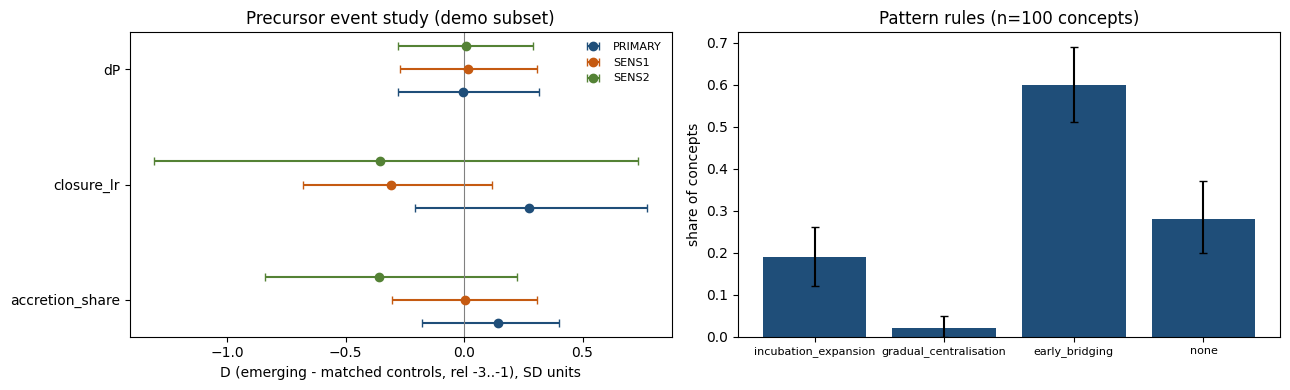

event_study_precursors.png


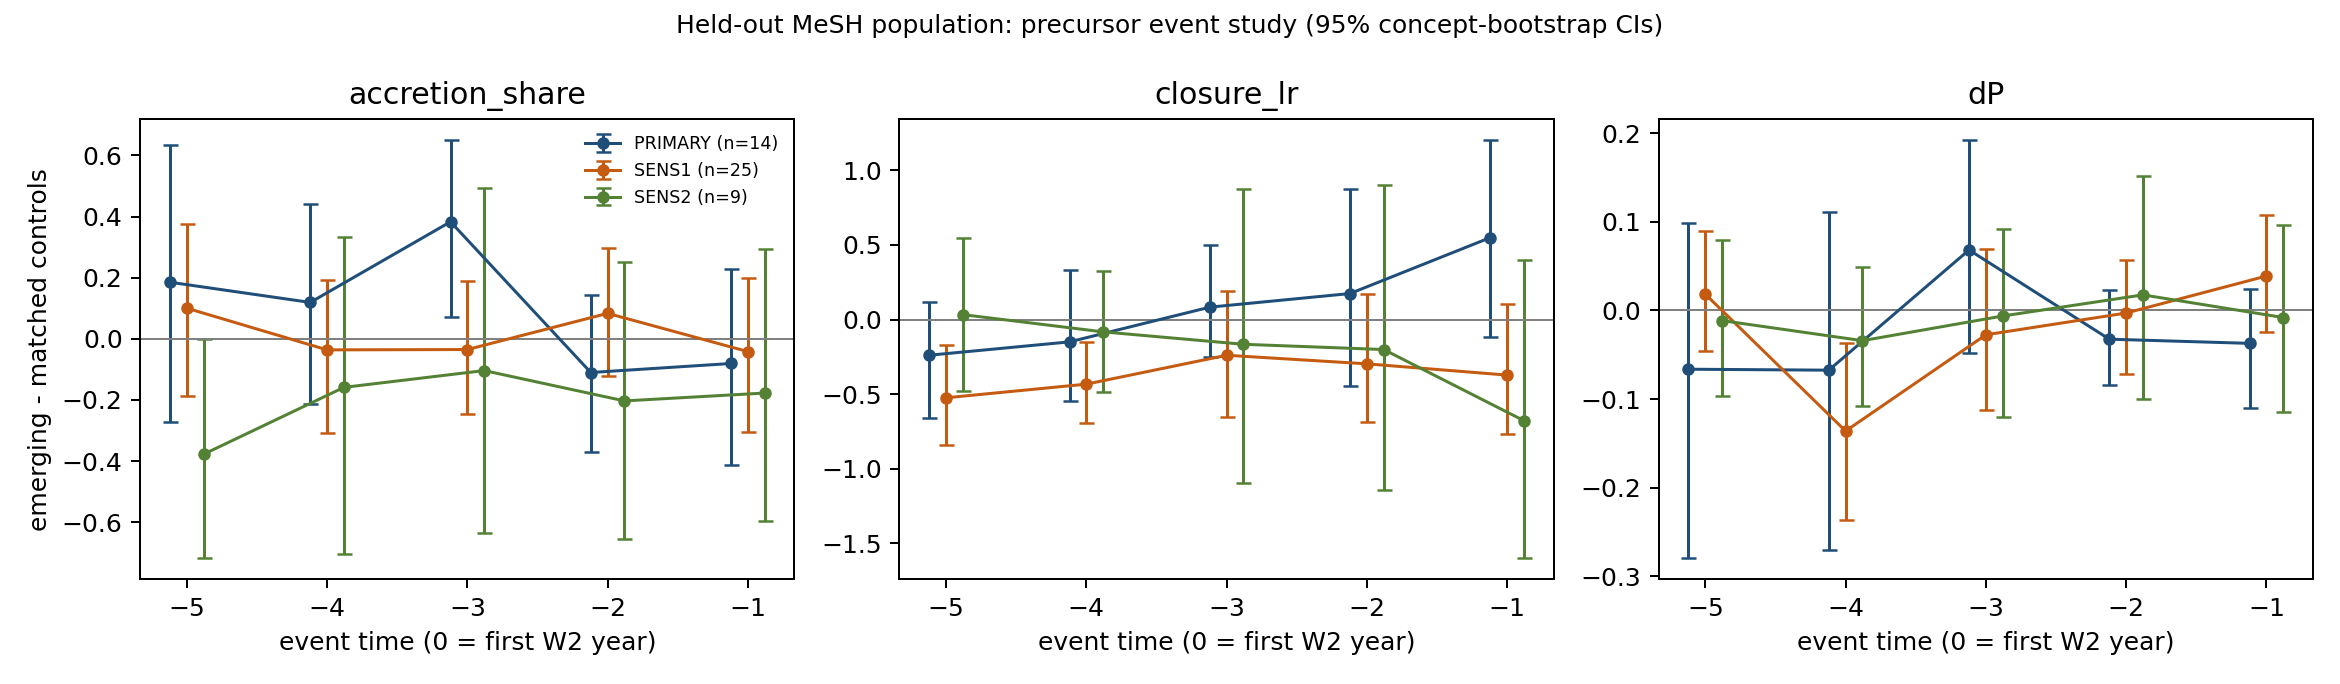

side_by_side_mainpool_vs_mesh.png


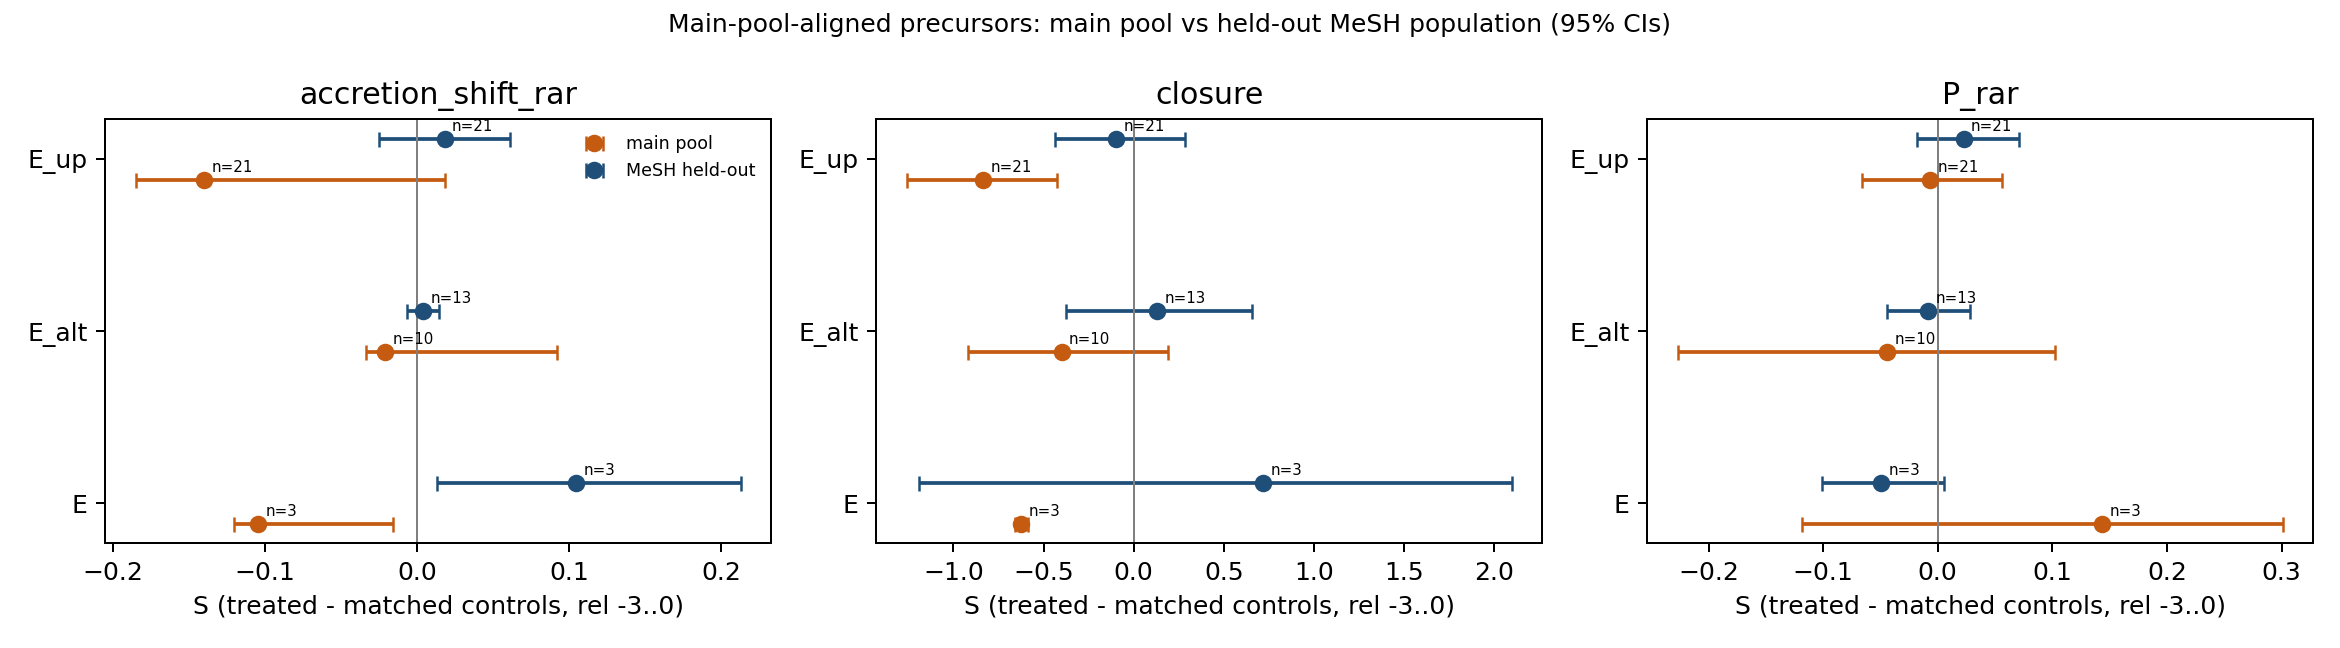

delta_auc_forest.png


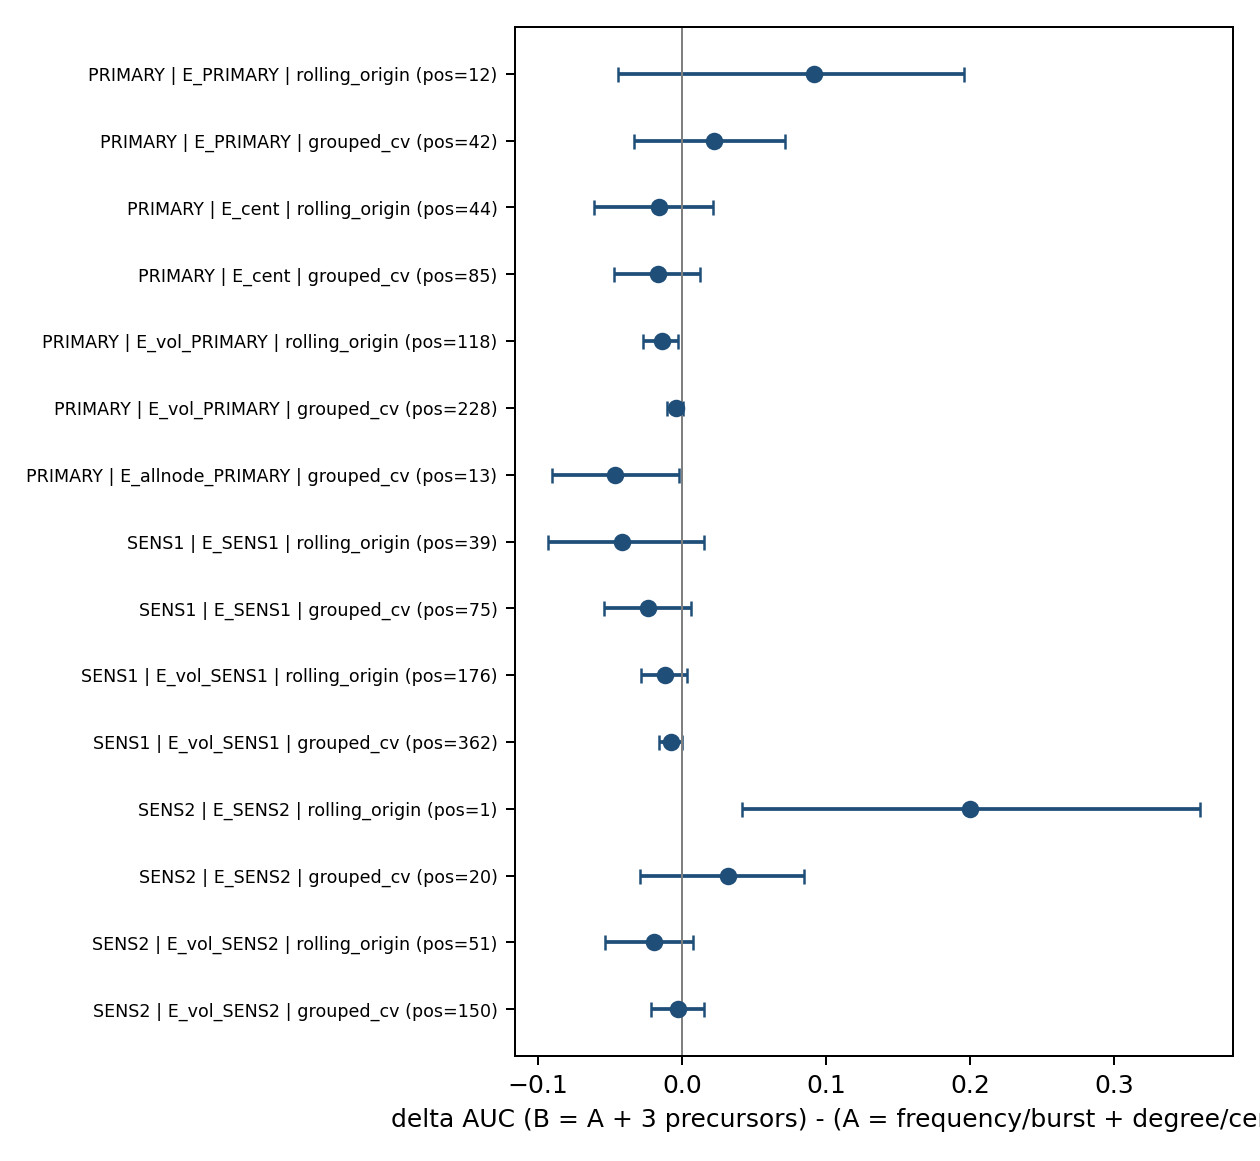

pattern_frequencies.png


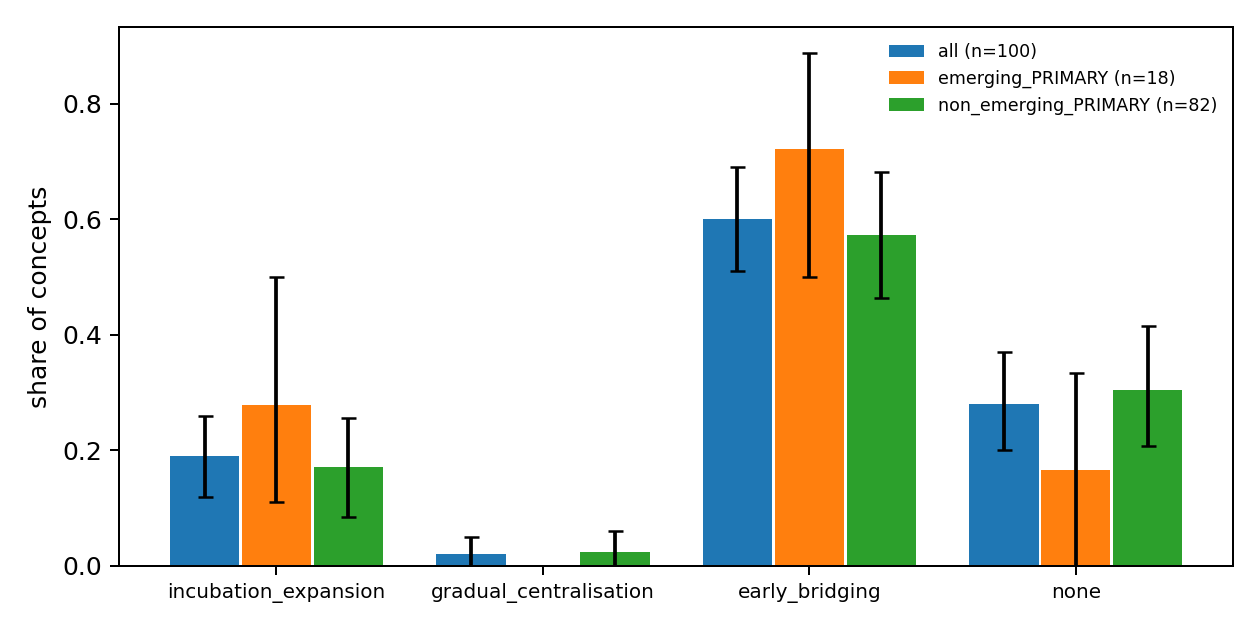

In [26]:
# compact overview: standardized precursor effects (D in SD units, 95% CI) per volume definition + pattern shares
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
sd_units = Dtab.copy()
_unit = (feat.age >= S.AGE_RANGE[0]) & (feat.age <= S.AGE_RANGE[1]) & (feat.year <= S.T_MAX)
sd_units["sd"] = [1.0 / float(feat.loc[_unit, c].std()) for c in sd_units.column]  # same sd_ref as run_event_studies
colors = {"PRIMARY": "#1f4e79", "SENS1": "#c55a11", "SENS2": "#548235"}
for j, p in enumerate(S.PRECURSORS):
    for i, vd in enumerate(["PRIMARY", "SENS1", "SENS2"]):
        r = sd_units[(sd_units.indicator == p) & (sd_units.volume_def == vd) & (sd_units.outcome == "E")]
        if r.empty or not np.isfinite(r["diff_sd"].iloc[0]):
            continue
        r = r.iloc[0]
        y = j + (i - 1) * 0.2
        ax.errorbar(r.diff_sd, y, xerr=[[r.diff_sd - r.ci_lo * r.sd], [r.ci_hi * r.sd - r.diff_sd]], fmt="o",
                    color=colors[vd], capsize=3, label=f"{vd}" if j == 0 else None)
ax.axvline(0, color="grey", lw=0.8)
ax.set_yticks(range(len(S.PRECURSORS)))
ax.set_yticklabels(S.PRECURSORS)
ax.set_xlabel("D (emerging - matched controls, rel -3..-1), SD units")
ax.set_title("Precursor event study (demo subset)")
ax.legend(frameon=False, fontsize=8)
ax = axes[1]
pp = pat_tab[pat_tab.group == "all"]
ax.bar(pp.pattern, pp.freq, yerr=[pp.freq - pp.ci_lo, pp.ci_hi - pp.freq], color="#1f4e79", capsize=3)
ax.set_ylabel("share of concepts")
ax.set_title(f"Pattern rules (n={int(pp.n.max())} concepts)")
ax.tick_params(axis="x", labelsize=8)
fig.tight_layout()
plt.show()

for f in ["event_study_precursors.png", "side_by_side_mainpool_vs_mesh.png", "delta_auc_forest.png", "pattern_frequencies.png"]:
    if (FIG / f).exists():
        print(f)
        display(Image(filename=str(FIG / f), width=900))